# Folk software and the traces left by AI builder tools

DSM050 Data Visualisation, final coursework.

This notebook examines the saved repository data and the completed judge evaluations.
The sampling groups follow the tools that left traces in each repository. A maker's
occupation remains uncertain, which matters when reading the comparisons below.

To reproduce the analysis, install `requirements.txt` and run
`python tools/run_notebook.py` from the repository root. The runner starts a fresh
Python kernel and saves the outputs here. JupyterLab can also open this notebook.
The analysis works from either the repository root or the `notebooks/` directory.

The inputs are the repository records in `data/processed/corpus.csv`, the separate
archive-host counts in `data/processed/wayback_census.csv`, and the final labels,
model checkpoints and sampling definitions in `data/processed/alignment/`.
The data statement in `data/README.md` explains their sources and limitations.

The analysis reads these files without making API requests. Charts are saved as
PNG and PDF files in `figures/`, with the numerical tables beside them.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore", message="Converting to PeriodArray.*")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import folkviz as fv
import codebook as cb

fv.use_house_style()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

RANDOM_SEED = 20260912   # fixed so every figure is reproducible
np.random.seed(RANDOM_SEED)

print("python", sys.version.split()[0], "| pandas", pd.__version__, "| seed", RANDOM_SEED)

# Embed exported figures in Jupyter while retaining ordinary Python compatibility.
try:
    from IPython.display import display, Image
except ImportError:
    display = None
if display is not None:
    _save_figure = fv.save
    def save_and_display(fig, name, caption_text=None):
        _save_figure(fig, name, caption_text)
        display(Image(filename=str(ROOT / "figures" / f"{name}.png")))
    fv.save = save_and_display

python 3.14.6 | pandas 2.3.3 | seed 20260912


## 1. Load the corpus

In [2]:
corpus_path = ROOT / "data" / "processed" / "corpus.csv"
census_path = ROOT / "data" / "processed" / "wayback_census.csv"

df = pd.read_csv(corpus_path, low_memory=False)
census = pd.read_csv(census_path, low_memory=False) if census_path.exists() else pd.DataFrame()

for c in ["created_at", "pushed_at", "updated_at", "owner_account_created",
          "wayback_first_seen", "wayback_last_seen", "collected_utc"]:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce", utc=True)

print(f"{len(df):,} repositories, {df.shape[1]} columns")
print(f"date range: {df['created_at'].min():%Y-%m-%d} to {df['created_at'].max():%Y-%m-%d}")
print()
print(df["stratum"].value_counts().to_string())

50,396 repositories, 37 columns
date range: 2011-09-20 to 2026-09-12

stratum
lovable    42264
replit      2797
v0_bolt     2776
claude      2559


## 2. Data overview and preprocessing

The preparation decisions follow the questions the data can answer. Forks are
excluded because they can inherit another project's tool marker. Auto-generated
names remain in the corpus, but are excluded from genre shares. A name such as
`aurora-echo-verse` may describe the builder's naming system rather than the
maker's intended application.

Dead applications remain in the analysis because the fourth question concerns
whether a published address still loads. Removing them would bias that result.
Missing core outcomes are left missing. Archive dates are especially sparse,
so they cannot support a study of how long the applications survived.

Account-footprint groups use the explicit defaults shown in the code. The separate
maker-score calculation fills a missing composite score with the stratum median.
These choices allow descriptive comparisons while leaving occupation unresolved.

In [3]:
n_raw = len(df)
df = df[~df["is_fork"].fillna(False).astype(bool)].copy()
print(f"dropped {n_raw - len(df):,} forks, {len(df):,} remain")

# Genre, purpose and durability intent, all from the maker's own project name.
df["genre"] = [cb.genre_combined(a, b) for a, b in
               zip(df["repo_slug"].fillna(""), df["page_title"].fillna(""))]
df["purpose"] = df["repo_slug"].map(cb.purpose)
df["auto_slug"] = df["repo_slug"].map(cb.is_auto_slug)
df["commercial"] = df["repo_slug"].map(cb.is_commercial)
df["ephemeral_intent"] = df["repo_slug"].map(cb.is_ephemeral)

# A live page title, where the app still answers, gives a second genre signal.
if "page_title" in df.columns:
    has_title = df["page_title"].notna() & (df["page_title"].astype(str).str.len() > 2)
    n_rescued = int((has_title & df["genre"].ne("Unclassified") &
                     df["repo_slug"].map(cb.genre).eq("Unclassified")).sum())
    print(f"{int(has_title.sum()):,} rows carry a live page title; "
          f"{n_rescued:,} of them rescued a genre the project name did not give")

folk = df[df["stratum"] == "lovable"].copy()      # the population of interest
pro  = df[df["stratum"] != "lovable"].copy()      # professional contrast strata
print(f"\nfolk n={len(folk):,}   other tool strata n={len(pro):,}")

dropped 0 forks, 50,396 remain


4,597 rows carry a live page title; 1,129 of them rescued a genre the project name did not give

folk n=42,264   other tool strata n=8,132


In [4]:
# Table 2: corpus summary, the table the report prints.
def summarise(g):
    live = g["live_class"].eq("live").sum() if "live_class" in g else np.nan
    checked = g["live_class"].notna().sum() if "live_class" in g else np.nan
    return pd.Series({
        "repositories": len(g),
        "date range": f"{g['created_at'].min():%b %Y} to {g['created_at'].max():%b %Y}",
        "median stars": g["stars"].median(),
        "% zero stars": 100 * g["stars"].eq(0).mean(),
        "% no description": 100 * (1 - g["has_description"].fillna(False).astype(bool).mean()),
        "median days active": g["days_repo_active"].median(),
        "% published URL known": 100 * g["app_host"].notna().mean() if "app_host" in g else np.nan,
        "% of checked URLs live": 100 * live / checked if checked else np.nan,
    })

table2 = df.groupby("stratum").apply(summarise).T
table2.columns = [fv.STRATUM_LABEL.get(c, c) for c in table2.columns]
table2.round(1).to_csv(ROOT / "figures" / "table2_corpus_summary.csv")
table2.round(1)

/var/folders/57/sq01fmg167n8wwfxp2l64ngh0000gq/T/ipykernel_29339/1752500803.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  table2 = df.groupby("stratum").apply(summarise).T


,Claude Code,Lovable (builder tool),Replit,v0 / Bolt
repositories,2559,42264,2797,2776
date range,Jun 2024 to Sep 2026,Jun 2024 to Sep 2026,Sep 2011 to Sep 2026,Jun 2024 to Sep 2026
median stars,0.0,0.0,0.0,0.0
% zero stars,78.66354,96.467443,79.013228,89.553314
% no description,41.422431,95.073822,50.840186,82.096542
median days active,20.0,0.0,6.0,106.0
% published URL known,16.25635,22.581866,30.139435,70.605187
% of checked URLs live,83.732057,80.538922,31.597222,81.182266


In [5]:
# Table 3: the maker proxies. Public data cannot give demographics, so these
# account-level proxies are what stands in for them, and the report says so.
def maker_profile(g):
    return pd.Series({
        "median public repos": g["owner_public_repos"].median(),
        "median followers": g["owner_followers"].median(),
        "% owners with 0 followers": 100 * g["owner_followers"].eq(0).mean(),
        "% with a bio": 100 * g["owner_has_bio"].fillna(False).astype(bool).mean(),
        "% with a company": 100 * g["owner_has_company"].fillna(False).astype(bool).mean(),
        "% account < 30 days old at repo": 100 * g["owner_account_age_days_at_repo"].lt(30).mean(),
        "median account age (days)": g["owner_account_age_days_at_repo"].median(),
    })

table3 = df.groupby("stratum").apply(maker_profile).T
table3.columns = [fv.STRATUM_LABEL.get(c, c) for c in table3.columns]
table3.round(1).to_csv(ROOT / "figures" / "table3_maker_proxies.csv")
table3.round(1)

/var/folders/57/sq01fmg167n8wwfxp2l64ngh0000gq/T/ipykernel_29339/686039823.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  table3 = df.groupby("stratum").apply(maker_profile).T


,Claude Code,Lovable (builder tool),Replit,v0 / Bolt
median public repos,18.0,10.0,14.0,14.0
median followers,1.0,0.0,1.0,1.0
% owners with 0 followers,36.7,64.4,48.1,49.6
% with a bio,33.0,20.5,37.0,31.9
% with a company,20.6,9.0,17.1,17.5
% account < 30 days old at repo,11.4,19.7,17.8,14.5
median account age (days),1425.0,370.0,506.0,593.0


## 3. RQ1. What do non-technical builders make?

Project names offer the most widely available description of what people made.
The dictionary in `src/codebook.py` assigns 23 genre families using ordered word
rules. A page title supplies additional text where one was collected.

The matching rule changed after an error was found. Substring matching had placed
names containing "space" in a category triggered by "spa". The revised rule
matches whole words, with stem matching for keywords of at least five characters.
It removes those particular false matches, although the gain in precision was
not measured independently.

Many names still remain unclassified. An invented name may reveal little about
an application, and the dictionary can miss words in other languages. The next
figure examines the words themselves. The separate dictionary-validation sheet
has no completed answers, so its category shares remain descriptive outputs.

saved figures/fig3_what_people_make.png and .pdf


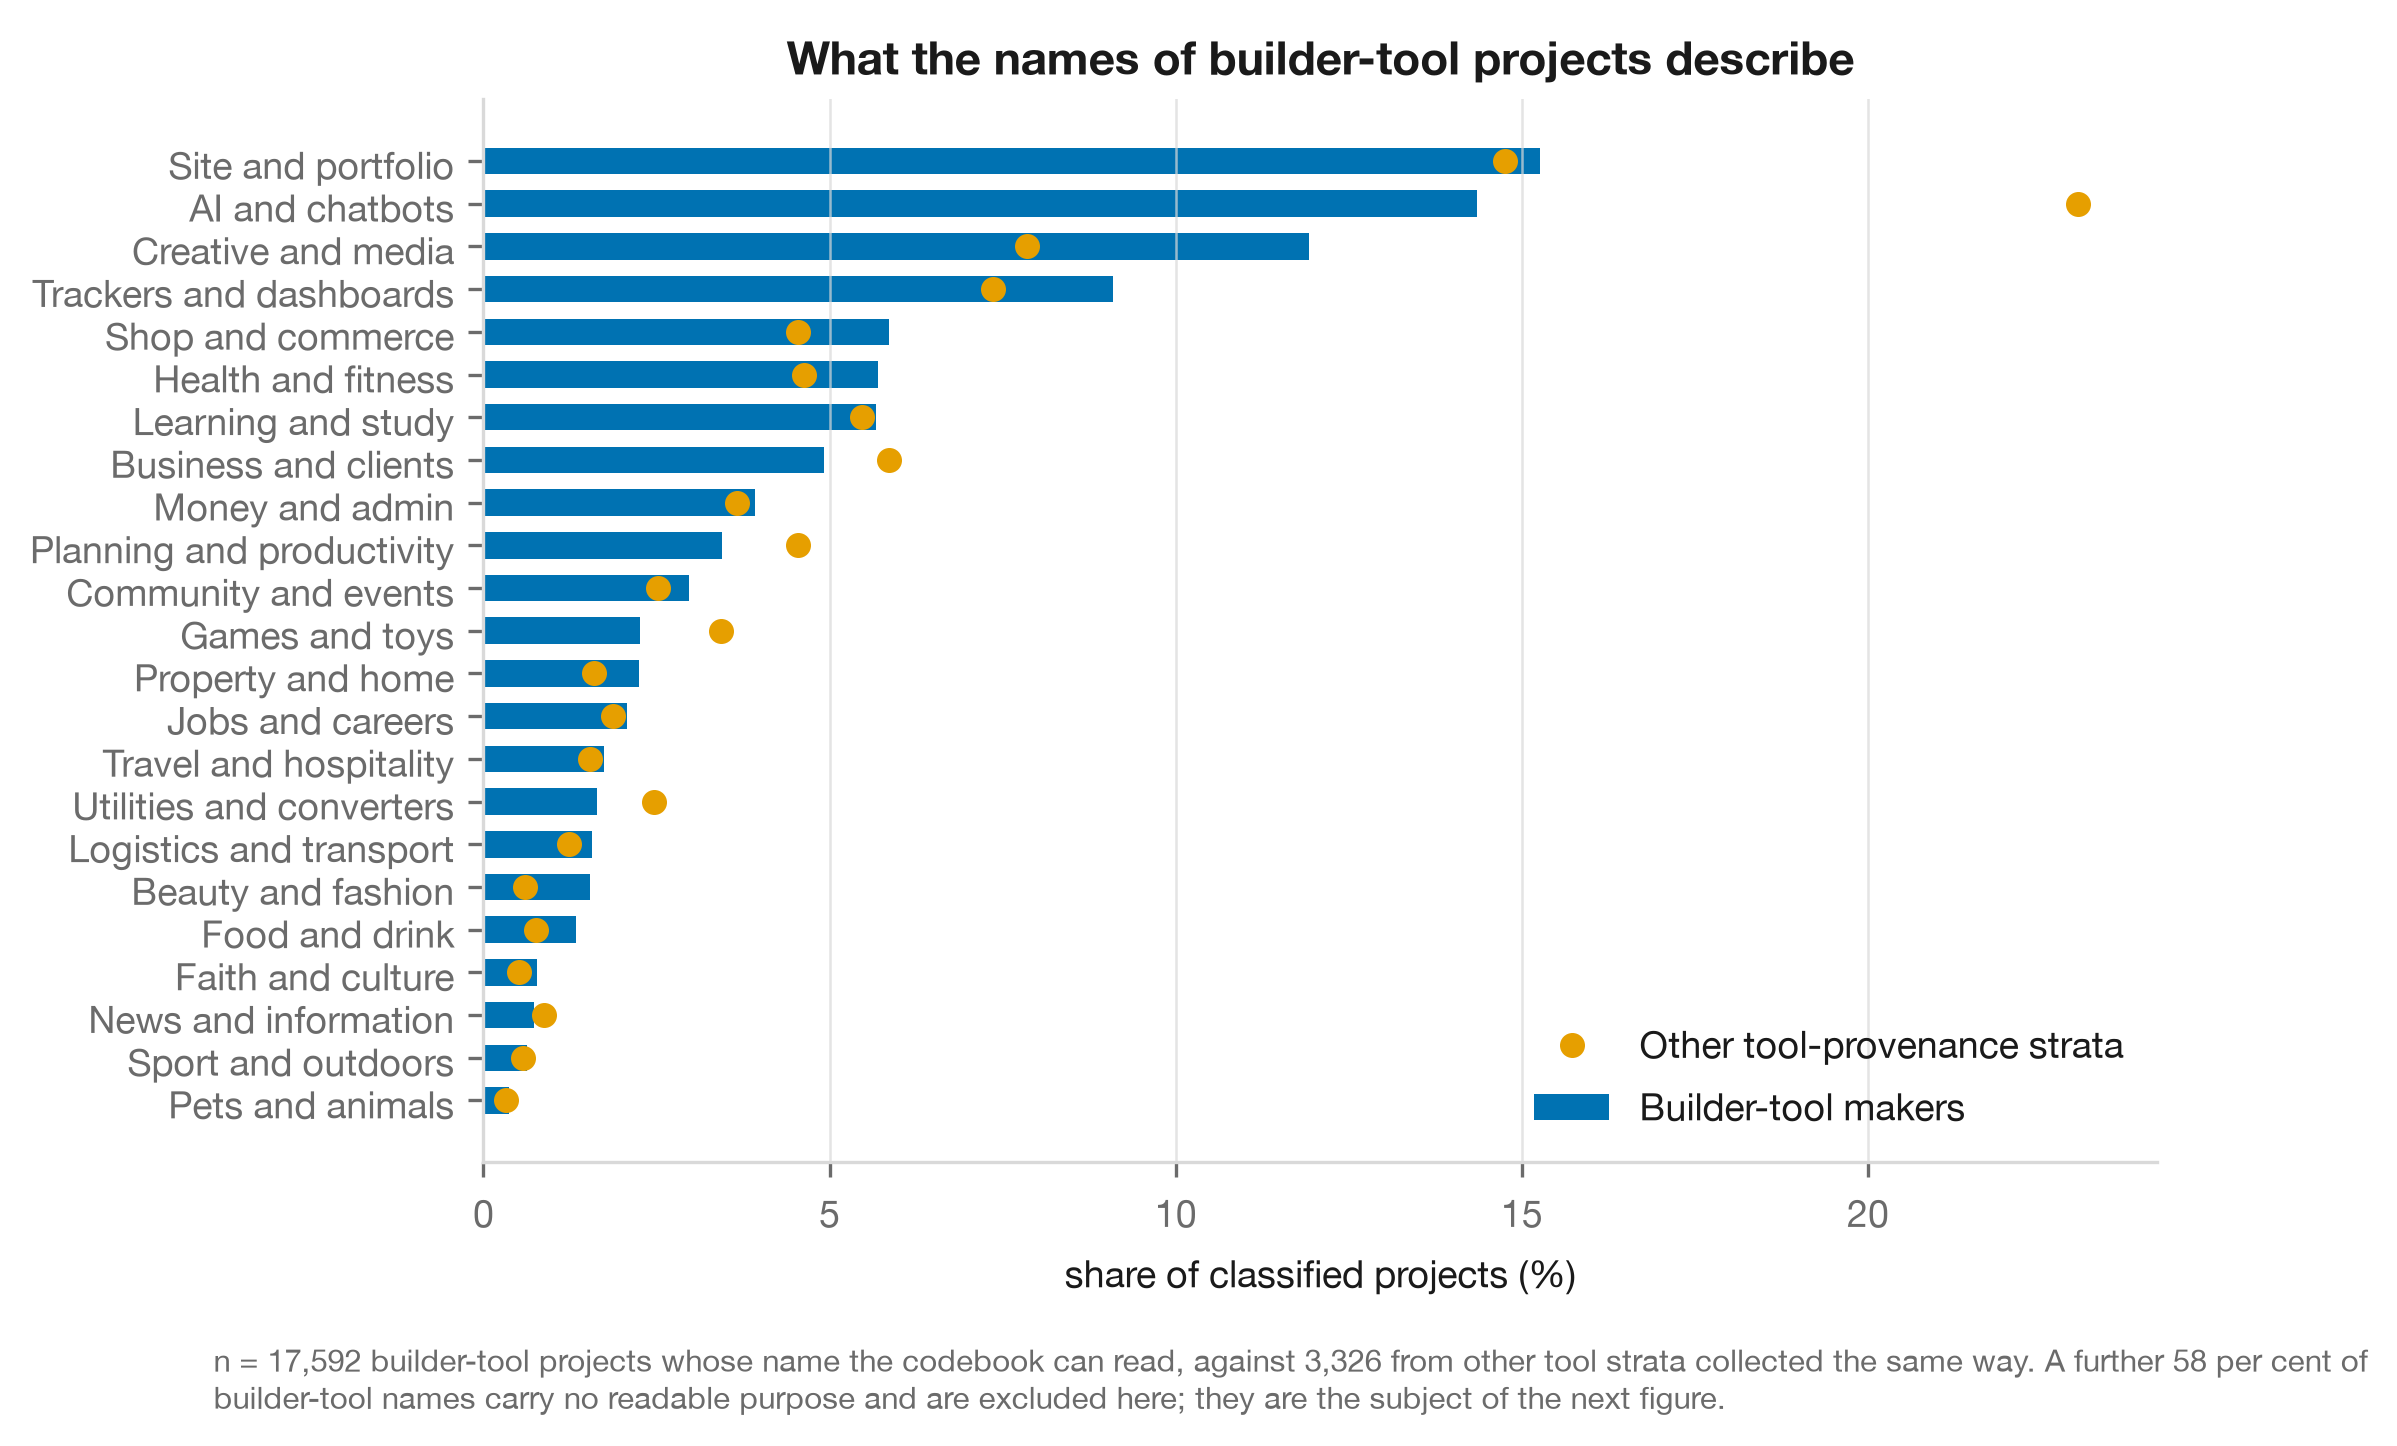

genre
Site and portfolio           2684
AI and chatbots              2524
Creative and media           2098
Trackers and dashboards      1601
Shop and commerce            1030
Health and fitness           1002
Learning and study            997
Business and clients          865
Money and admin               689
Planning and productivity     605
Community and events          522
Games and toys                398
Property and home             395
Jobs and careers              365
Travel and hospitality        307
Name: count, dtype: int64

In [6]:
# Denominator: projects the codebook can actually read. Names it cannot classify
# and names that are purely product-style are excluded here and counted in their
# own right in the next figure, so every share in the report uses this same base.
UNREADABLE = ["Unclassified", "Generic or brand-style name"]
readable = lambda g: g.loc[~g["auto_slug"] & ~g["genre"].isin(UNREADABLE), "genre"]

genre_share = readable(folk).value_counts(normalize=True) * 100
genre_n = readable(folk).value_counts()
pro_share = readable(pro).value_counts(normalize=True) * 100

order = genre_share.index.tolist()
fig, ax = plt.subplots(figsize=(7.2, 4.6))
y = np.arange(len(order))
ax.barh(y, [genre_share.get(g, 0) for g in order], height=0.62,
        color=fv.STRATUM_COLOUR["lovable"], label="Builder-tool makers")
ax.plot([pro_share.get(g, 0) for g in order], y, "o", ms=5,
        color=fv.STRATUM_COLOUR["replit"], label="Other tool-provenance strata")
ax.set_yticks(y); ax.set_yticklabels(order)
ax.invert_yaxis()
ax.set_xlabel("share of classified projects (%)")
ax.set_title("What the names of builder-tool projects describe")
ax.legend(loc="lower right")
ax.grid(axis="y", visible=False)
fv.save(fig, "fig3_what_people_make",
        f"n = {len(readable(folk)):,} builder-tool projects whose name the codebook can read, against "
        f"{len(readable(pro)):,} from other tool strata collected the same way. A further "
        f"{100 * folk['genre'].isin(UNREADABLE).mean():.0f} per cent of builder-tool names carry no "
        "readable purpose and are excluded here; they are the subject of the next figure.")
genre_n.head(15)

saved figures/fig4_naming_vocabulary.png and .pdf


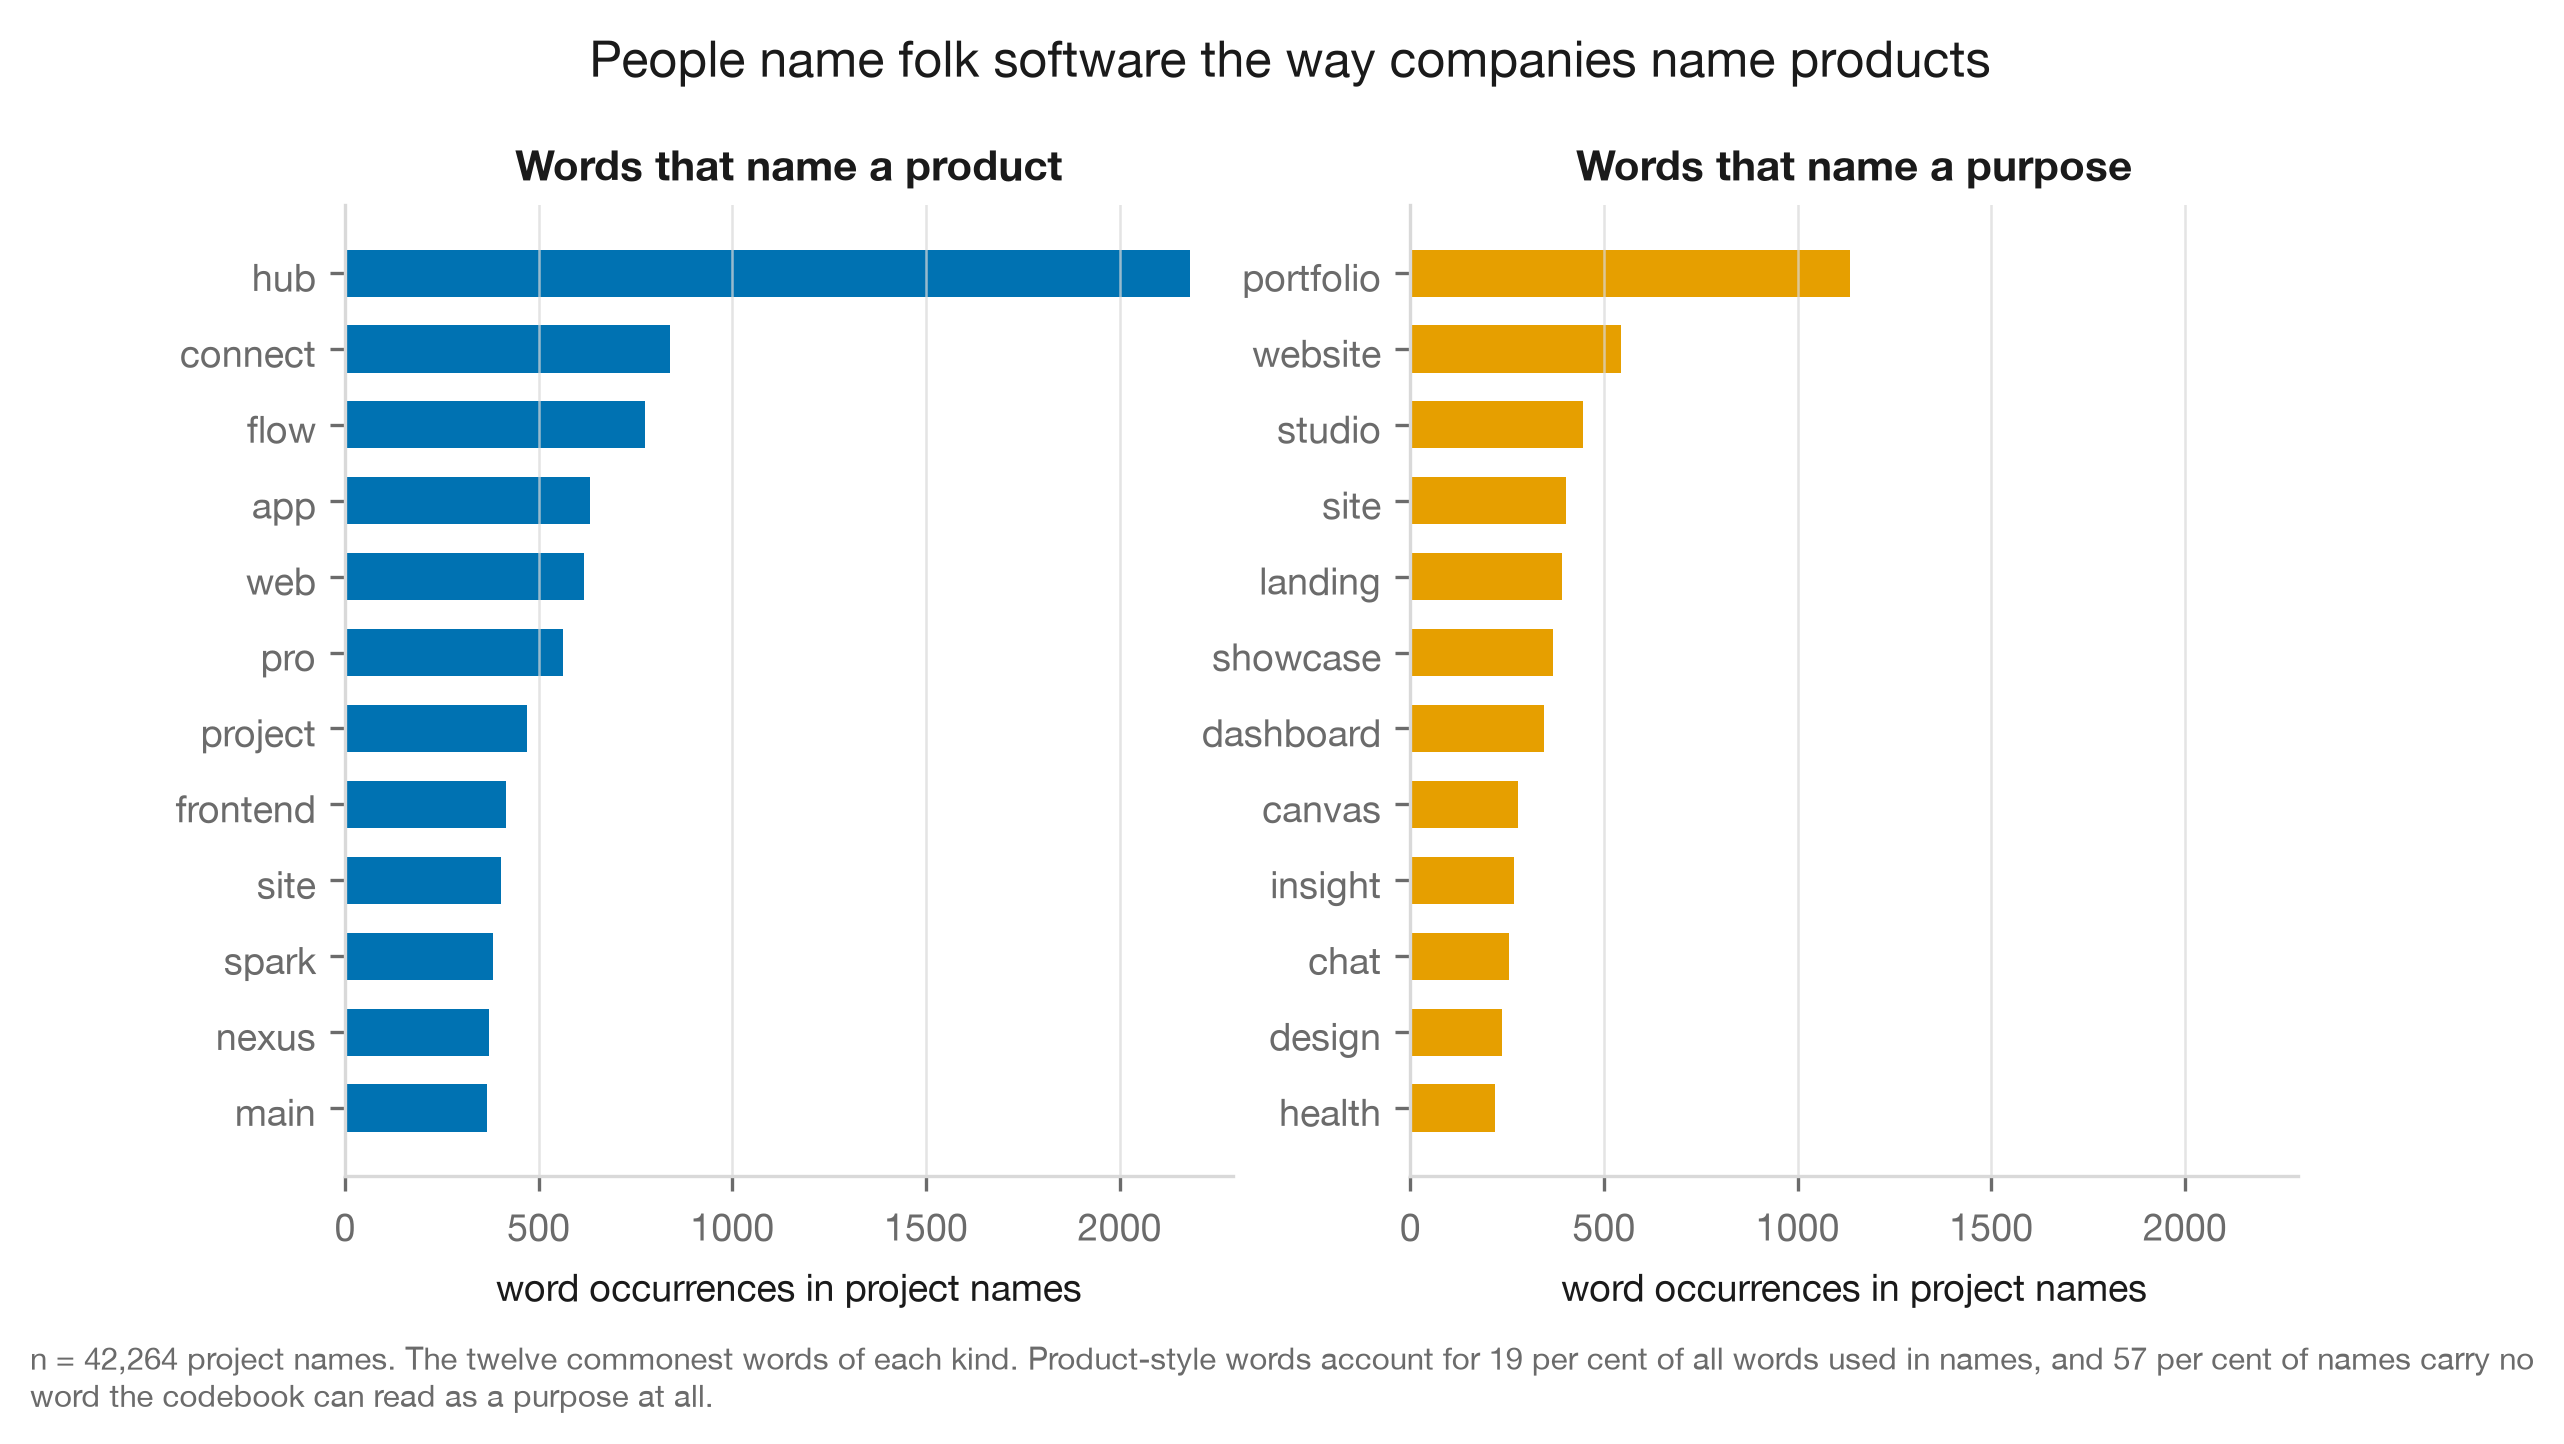

product-style words: 19.3% of all words in names
unclassifiable names: 57.4%


In [7]:
# A 2D projection of TF-IDF over two- and three-word names was tried first and
# abandoned: the vectors are too sparse and the projection collapsed onto two
# lines, which would have been a decorative figure making no claim. What the
# vocabulary does support is a finding about naming itself.
#
# Product-style and function words can coexist in the same name. The two panels
# show token frequency. They do not establish that every project has a brand name.
from collections import Counter

def word_bag(series):
    c = Counter()
    for name in series.dropna().astype(str):
        for w in cb.words(name):
            if len(w) > 2 and not w.isdigit():
                c[w] += 1
    return c

bag = word_bag(folk["repo_slug"])
generic = set(cb.GENERIC_NAME_TOKENS)
function = {t.strip("-") for toks in cb.GENRE_RULES.values() for t in toks}

top_form = [(w, n) for w, n in bag.most_common(400) if w in generic][:12]
top_func = [(w, n) for w, n in bag.most_common(400)
            if w in function or any(w.startswith(f) for f in function if len(f) >= 5)][:12]

fig, axes = plt.subplots(1, 2, figsize=(8.4, 4.2), sharex=True)
for ax, pairs, title, colour in [
    (axes[0], top_form, "Words that name a product", fv.STRATUM_COLOUR["lovable"]),
    (axes[1], top_func, "Words that name a purpose", fv.STRATUM_COLOUR["replit"]),
]:
    ws = [w for w, _ in pairs][::-1]
    ns = [n for _, n in pairs][::-1]
    ax.barh(np.arange(len(ws)), ns, color=colour, height=0.62)
    ax.set_yticks(np.arange(len(ws))); ax.set_yticklabels(ws)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("word occurrences in project names")
    ax.grid(axis="y", visible=False)

share_form = 100 * sum(n for w, n in bag.items() if w in generic) / max(1, sum(bag.values()))
fig.suptitle("People name folk software the way companies name products", y=1.02)
fv.save(fig, "fig4_naming_vocabulary",
        f"n = {len(folk):,} project names. The twelve commonest words of each kind. "
        f"Product-style words account for {share_form:.0f} per cent of all words used in names, and "
        f"{100 * folk['genre'].eq('Unclassified').mean():.0f} per cent of names carry no word the "
        "codebook can read as a purpose at all.")
print(f"product-style words: {share_form:.1f}% of all words in names")
print(f"unclassifiable names: {100 * folk['genre'].eq('Unclassified').mean():.1f}%")

## 4. RQ2. Who makes it?

The repository data describes public accounts. Repository counts, followers and
account age provide a picture of those accounts, while the other tool groups
provide a comparison collected at the same time. These measures leave the
makers' occupations unresolved.

saved figures/fig5_who_makes_it.png and .pdf


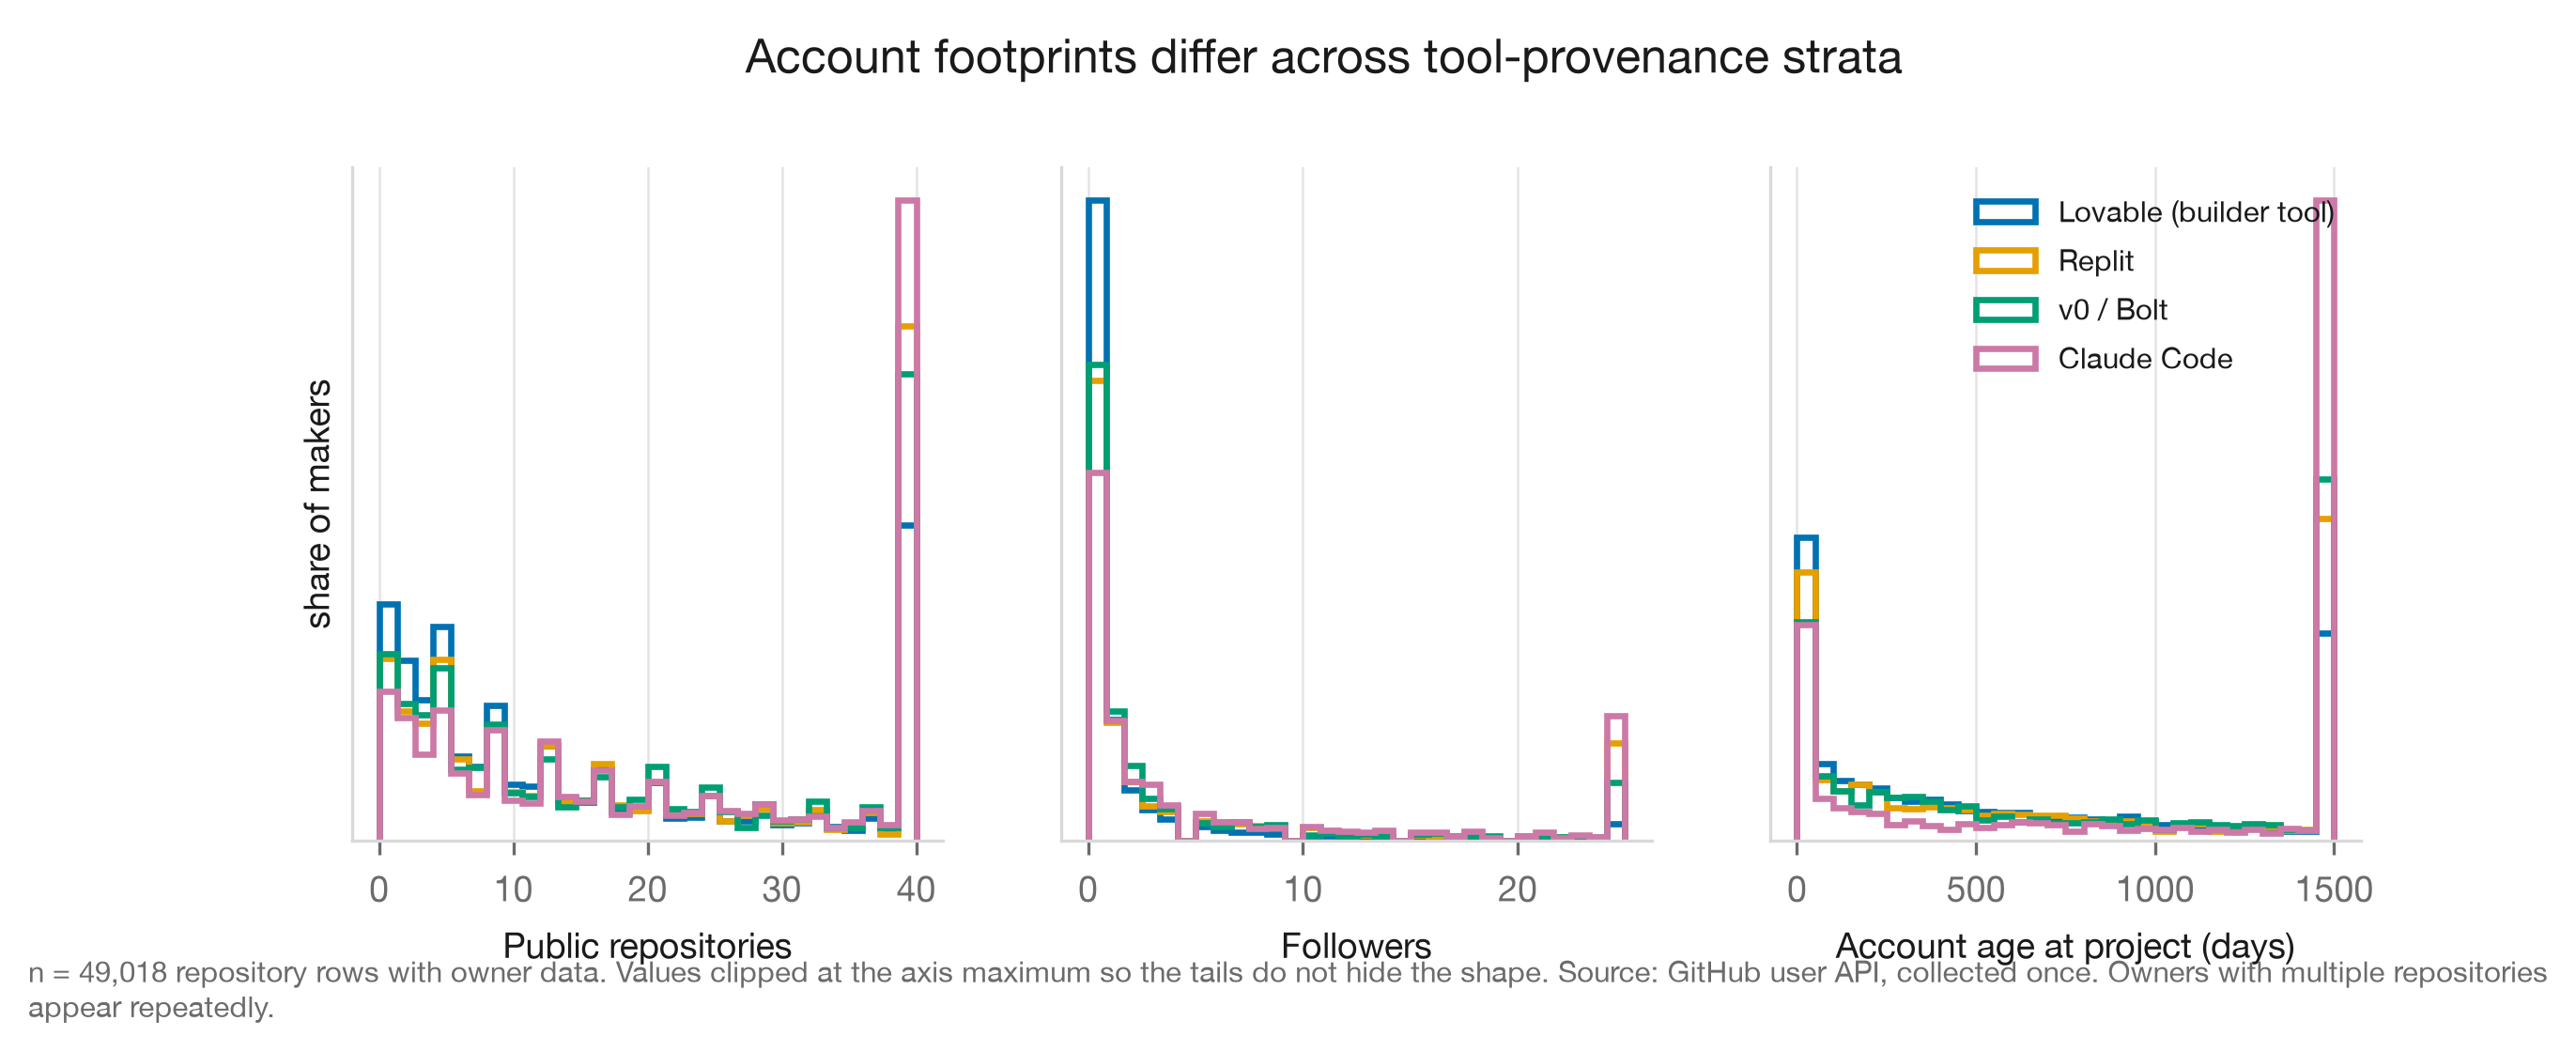

,Claude Code,Lovable (builder tool),Replit,v0 / Bolt
median public repos,18.0,10.0,14.0,14.0
median followers,1.0,0.0,1.0,1.0
% owners with 0 followers,36.7,64.4,48.1,49.6
% with a bio,33.0,20.5,37.0,31.9
% with a company,20.6,9.0,17.1,17.5
% account < 30 days old at repo,11.4,19.7,17.8,14.5
median account age (days),1425.0,370.0,506.0,593.0


In [8]:
metrics = [
    ("owner_public_repos", "Public repositories", (0, 40)),
    ("owner_followers", "Followers", (0, 25)),
    ("owner_account_age_days_at_repo", "Account age at project (days)", (0, 1500)),
]
fig, axes = plt.subplots(1, 3, figsize=(9.2, 3.1))
for ax, (col, label, xlim) in zip(axes, metrics):
    for st in ["lovable", "replit", "v0_bolt", "claude"]:
        v = df.loc[df["stratum"] == st, col].dropna()
        if len(v) < 30:
            continue
        v = v.clip(*xlim)
        ax.hist(v, bins=30, range=xlim, density=True, histtype="step", lw=1.6,
                color=fv.STRATUM_COLOUR[st], label=fv.STRATUM_LABEL[st])
    ax.set_xlabel(label); ax.set_yticks([])
    ax.grid(axis="y", visible=False)
axes[0].set_ylabel("share of makers")
axes[-1].legend(fontsize=7.5, loc="upper right")
fig.suptitle("Account footprints differ across tool-provenance strata", y=1.04)
fv.save(fig, "fig5_who_makes_it",
        f"n = {df['owner_public_repos'].notna().sum():,} repository rows with owner data. Values clipped at the axis "
        "maximum so the tails do not hide the shape. Source: GitHub user API, collected once. Owners with multiple repositories appear repeatedly.")
table3.round(1)

## 5. RQ3. Who is folk software for?

Some names contain words associated with business, such as invoice, pricing or
checkout. Others refer to a person or household. The monthly chart compares
those two dictionary signals. They describe the language in project names,
with limited evidence about the intended audience and none about earnings.

saved figures/fig6_commerce_gradient.png and .pdf


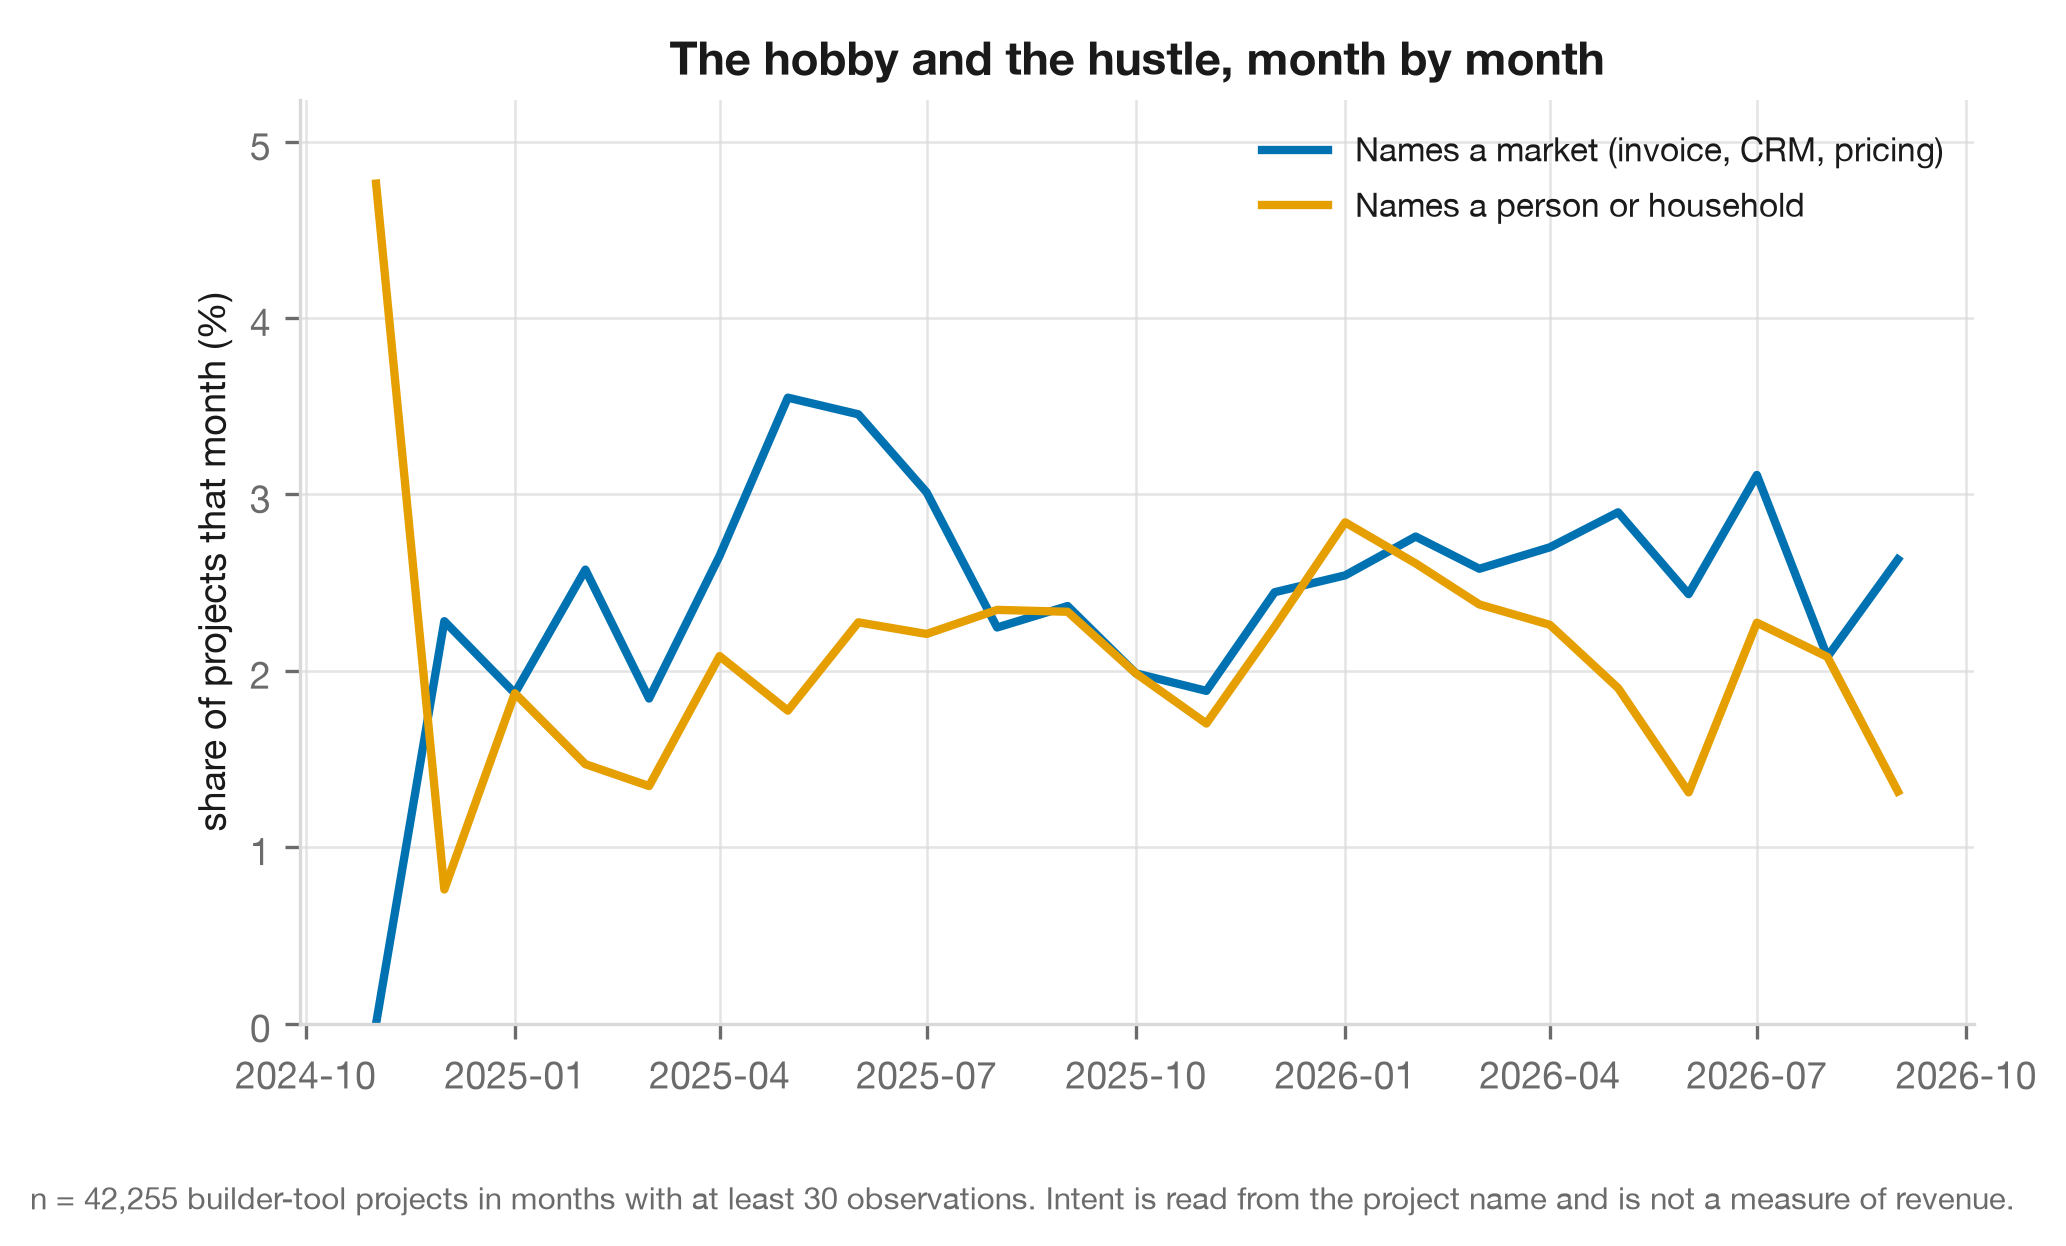

,n,commercial,personal
month,,,
2025-10-01,2770,0.020,0.020
2025-11-01,2704,0.019,0.017
2025-12-01,3067,0.024,0.022
2026-01-01,2991,0.025,0.028
2026-02-01,3948,0.028,0.026
2026-03-01,3956,0.026,0.024
2026-04-01,3185,0.027,0.023
2026-05-01,1104,0.029,0.019
2026-06-01,534,0.024,0.013


In [9]:
folk_m = folk.dropna(subset=["created_at"]).copy()
folk_m["month"] = folk_m["created_at"].dt.to_period("M").dt.to_timestamp()
by_month = folk_m.groupby("month").agg(
    n=("repo_id", "size"),
    commercial=("commercial", "mean"),
    personal=("purpose", lambda s: (s == "For self or circle").mean()),
)
by_month = by_month[by_month["n"] >= 30]

fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.plot(by_month.index, 100 * by_month["commercial"], lw=2,
        color=fv.STRATUM_COLOUR["lovable"], label="Names a market (invoice, CRM, pricing)")
ax.plot(by_month.index, 100 * by_month["personal"], lw=2,
        color=fv.STRATUM_COLOUR["replit"], label="Names a person or household")
ax.set_ylim(0, max(5, 110 * by_month[["commercial", "personal"]].max().max()))
ax.set_ylabel("share of projects that month (%)")
ax.set_title("The hobby and the hustle, month by month")
ax.legend(loc="upper right", fontsize=8)
fv.save(fig, "fig6_commerce_gradient",
        f"n = {int(by_month['n'].sum()):,} builder-tool projects in months with at least 30 observations. "
        "Intent is read from the project name and is not a measure of revenue.")
by_month.tail(12).round(3)

## 6. RQ4. Is folk software made to last, and does it?

Each checked address has one recorded response. The comparison therefore measures
the share that loaded at that check. Failure dates were not observed, and a
single failed request cannot distinguish temporary failure from abandonment.
The earlier survival curve was withdrawn because it assigned death dates that
the data did not contain.

The chart includes `live` and `dead_404` results. Blocked and indeterminate
responses are counted separately. Wilson intervals describe uncertainty within
the checked subset. They do not account for how that subset was selected.
Differences between tool groups may reflect hosting, billing or sampling, but
the data cannot separate those explanations. Names suggesting one-off use are
compared as a descriptive check. Section 5 provides the time-series analysis.

saved figures/fig7_made_to_last.png and .pdf


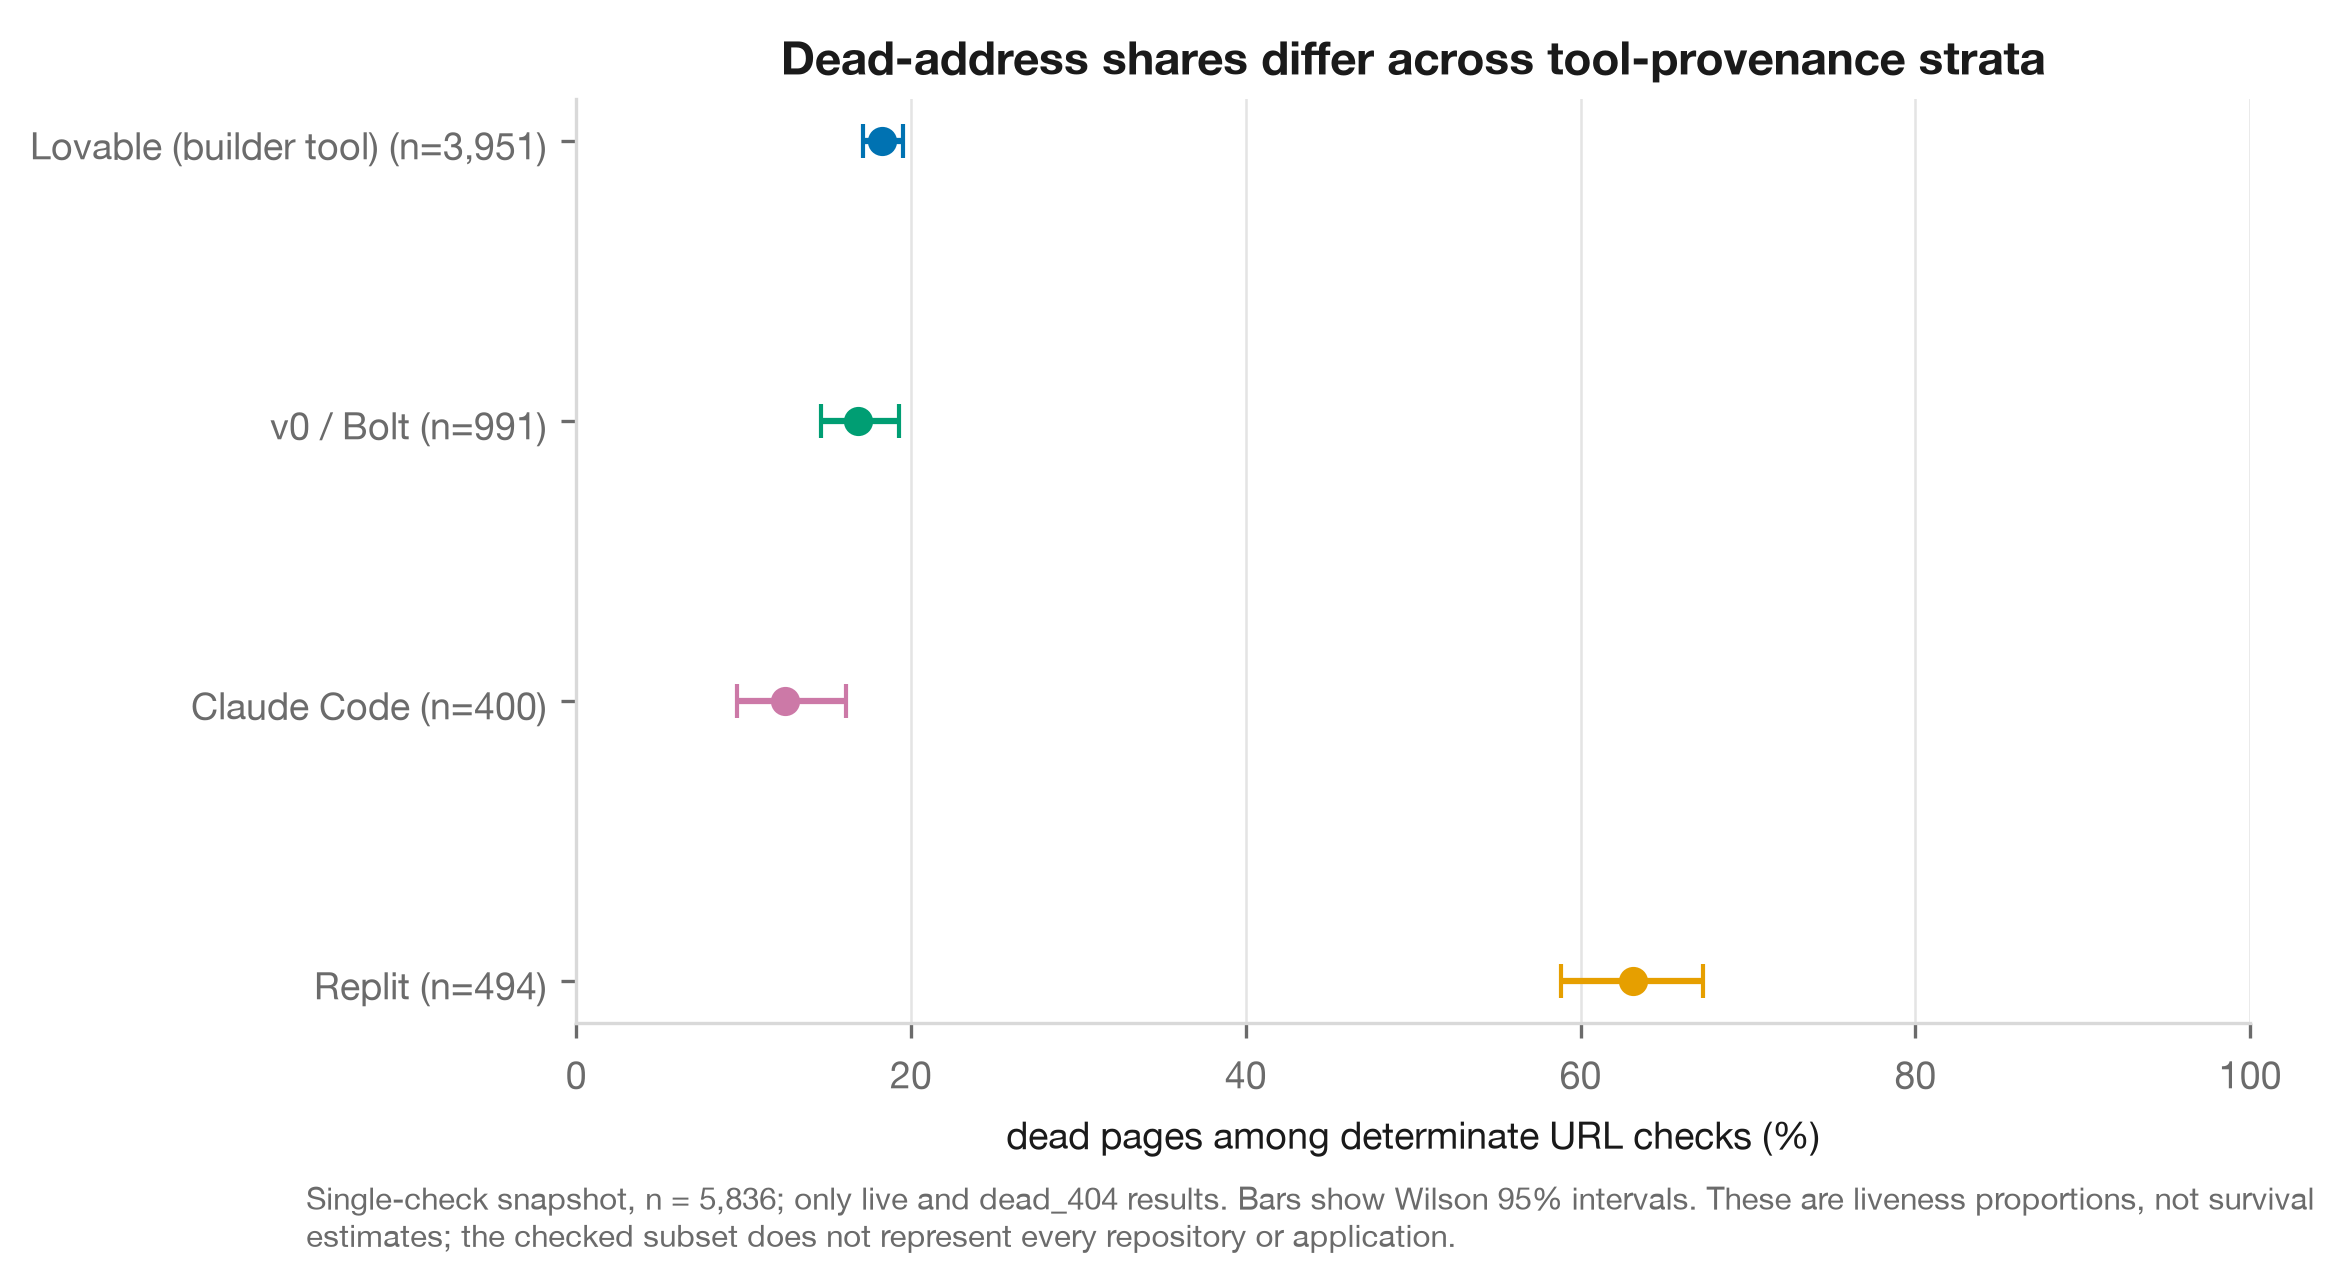

stratum  checked determinate  live  live share  wilson low  wilson high
lovable                 3951  3228      0.8170      0.8046       0.8288
v0_bolt                  991   824      0.8315      0.8069       0.8535
 claude                  400   350      0.8750      0.8390       0.9039
 replit                  494   182      0.3684      0.3271       0.4118
Excluded 181 indeterminate/blocked checks.
One-off name signal versus other names, builder-tool stratum:
                  size   mean
ephemeral_intent             
False             3861  0.183
True                90  0.189


In [10]:
from score_validation import wilson

surv = df[df["live_class"].isin(["live", "dead_404"])].copy()
surv["died"] = surv["live_class"].eq("dead_404").astype(int)
live_rows = []
for st in ["lovable", "v0_bolt", "claude", "replit"]:
    g = surv[surv["stratum"] == st]
    if g.empty:
        continue
    n, live = len(g), int(g["live_class"].eq("live").sum())
    share, lo, hi = wilson(live, n)
    live_rows.append({"stratum": st, "checked determinate": n, "live": live,
                      "live share": share, "wilson low": lo, "wilson high": hi})
live_table = pd.DataFrame(live_rows)
fig, ax = plt.subplots(figsize=(7.2, 4.0))
for y, row in live_table.iterrows():
    ax.errorbar(100 * (1 - row["live share"]), y,
                xerr=[[100 * (row["wilson high"] - row["live share"])],
                      [100 * (row["live share"] - row["wilson low"])]],
                fmt="o", capsize=4, color=fv.STRATUM_COLOUR[row["stratum"]])
ax.set_yticks(range(len(live_table)))
ax.set_yticklabels([f"{fv.STRATUM_LABEL[r.stratum]} (n={r['checked determinate']:,})"
                    for _, r in live_table.iterrows()])
ax.invert_yaxis(); ax.set_xlim(0, 100)
ax.set_xlabel("dead pages among determinate URL checks (%)")
ax.set_title("Dead-address shares differ across tool-provenance strata")
ax.grid(axis="y", visible=False)
fv.save(fig, "fig7_made_to_last",
        f"Single-check snapshot, n = {len(surv):,}; only live and dead_404 results. "
        "Bars show Wilson 95% intervals. These are liveness proportions, not survival estimates; "
        "the checked subset does not represent every repository or application.")
live_table.to_csv(ROOT / "figures" / "table_liveness_snapshot.csv", index=False)
print(live_table.round(4).to_string(index=False))
print(f"Excluded {df['live_class'].notna().sum() - len(surv):,} indeterminate/blocked checks.")
print("One-off name signal versus other names, builder-tool stratum:")
print(surv[surv["stratum"] == "lovable"].groupby("ephemeral_intent")["died"].agg(["size", "mean"]).round(3))

## 6b. What the census cannot see

The repository and archive sources cover overlapping populations. The repository
bars show successive limits on coverage against a vendor's total, reported at a
different date. The archive count is shown separately because it also includes
hosts without a public repository. These sources leave much of the wider
population unobserved.

saved figures/fig8_what_the_census_misses.png and .pdf


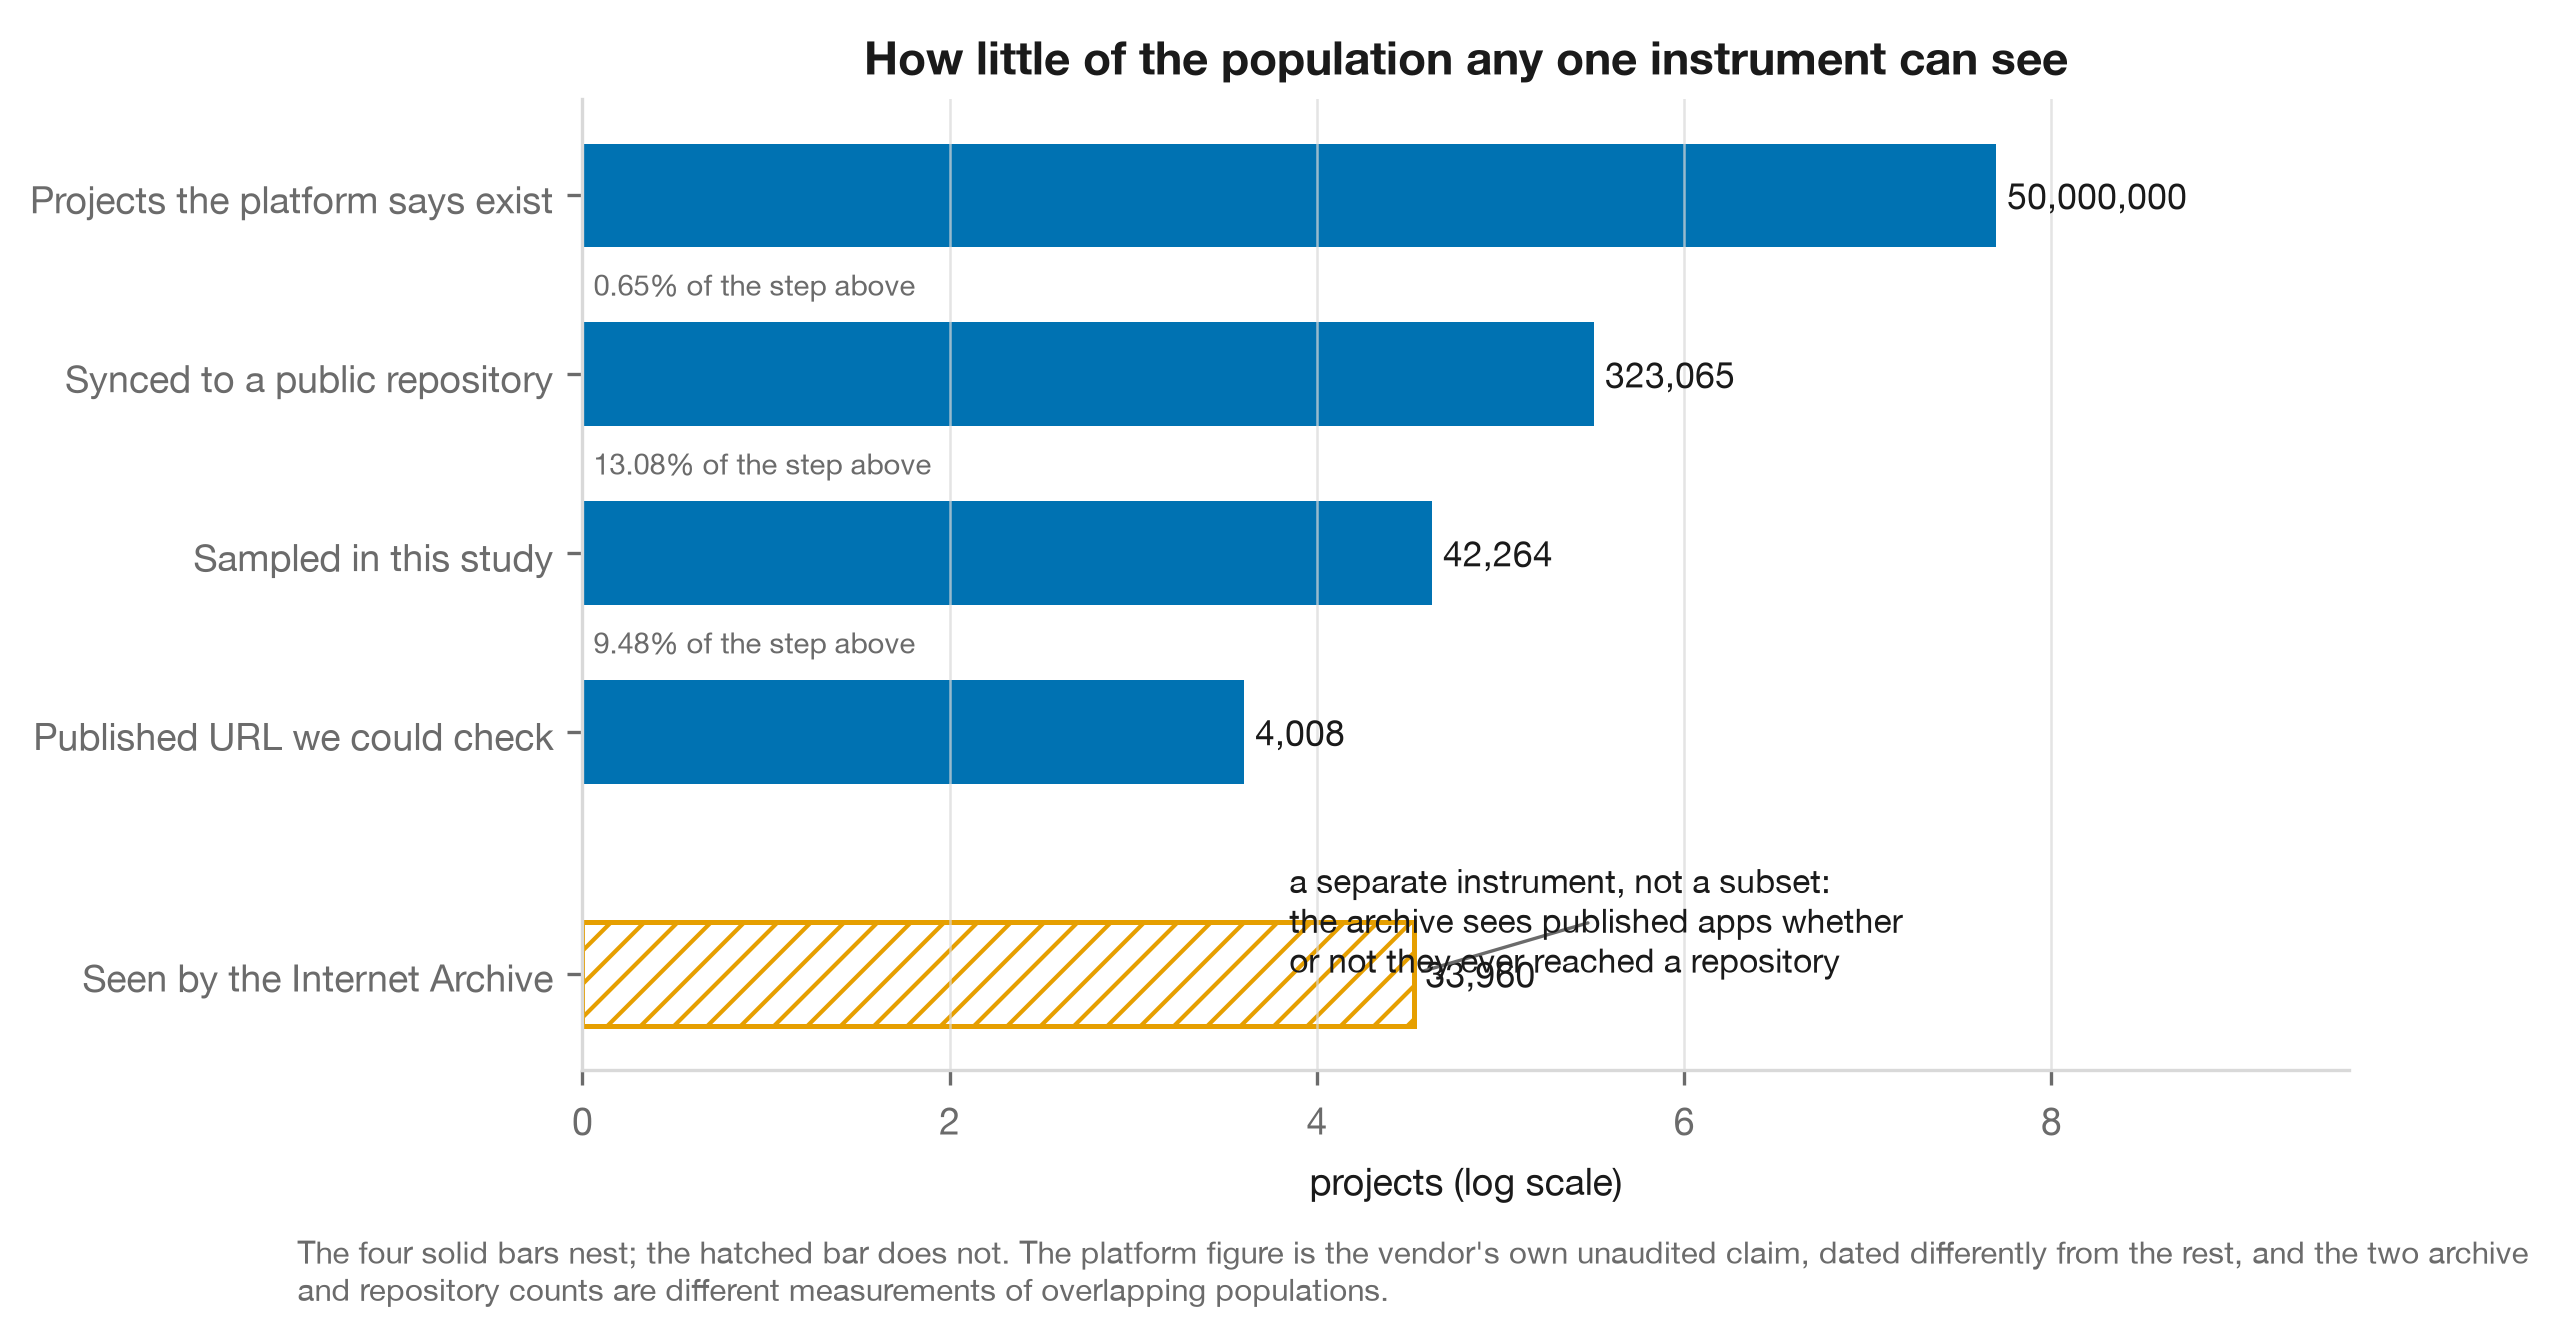

  50,000,000  Projects the platform says exist
     323,065  Synced to a public repository
      42,264  Sampled in this study
       4,008  Published URL we could check
      33,960  Seen by the Internet Archive (separate instrument)


In [11]:
# Two different instruments, and they do not nest. The archive sees published
# apps regardless of GitHub. GitHub sees repositories regardless of whether the
# app was ever archived. Drawing them as one funnel would imply a containment
# that does not exist, so the nested chain is drawn as a funnel and the archive
# is placed beside it as a separate probe.
VENDOR_CLAIM = 50_000_000     # the platform's own published figure, unaudited
GITHUB_TOTAL = 323_065        # repositories carrying the provenance signal (research/A)

nested = [
    ("Projects the platform says exist", VENDOR_CLAIM),
    ("Synced to a public repository", GITHUB_TOTAL),
    ("Sampled in this study", len(folk)),
    ("Published URL we could check", int(folk["live_class"].notna().sum())),
]
archive_n = int((census["platform"].str.contains("lovable", case=False, na=False)).sum()) if len(census) else 0

fig, ax = plt.subplots(figsize=(7.6, 4.2))
y = np.arange(len(nested))
vals = [v for _, v in nested]
ax.barh(y, np.log10(vals), height=0.58, color=fv.STRATUM_COLOUR["lovable"])
for i, v in enumerate(vals):
    ax.text(np.log10(v) + 0.06, i, f"{v:,}", va="center", fontsize=8.5)
    if i:
        pct = 100 * v / vals[i - 1]
        ax.text(0.06, i - 0.5, f"{pct:.2f}% of the step above", fontsize=7, color=fv.MUTED, va="center")

if archive_n:
    ax.barh([len(nested) + 0.35], [np.log10(archive_n)], height=0.58,
            color="white", edgecolor=fv.STRATUM_COLOUR["replit"], hatch="///", lw=1.2)
    ax.text(np.log10(archive_n) + 0.06, len(nested) + 0.35, f"{archive_n:,}", va="center", fontsize=8.5)

ticks = list(y) + ([len(nested) + 0.35] if archive_n else [])
names = [n for n, _ in nested] + (["Seen by the Internet Archive"] if archive_n else [])
ax.set_yticks(ticks); ax.set_yticklabels(names); ax.invert_yaxis()
ax.set_xlabel("projects (log scale)")
ax.set_xlim(0, np.log10(max(vals)) * 1.25)
ax.set_title("How little of the population any one instrument can see")
ax.grid(axis="y", visible=False)
if archive_n:
    fv.annotate(ax, "a separate instrument, not a subset:\nthe archive sees published apps whether\nor not they ever reached a repository",
                xy=(np.log10(archive_n), len(nested) + 0.35), xytext=(0.40, 0.10), textcoords="axes fraction")
fv.save(fig, "fig8_what_the_census_misses",
        "The four solid bars nest; the hatched bar does not. The platform figure is the vendor's own "
        "unaudited claim, dated differently from the rest, and the two archive and repository counts "
        "are different measurements of overlapping populations.")
for n, v in nested: print(f"{v:>12,}  {n}")
print(f"{archive_n:>12,}  Seen by the Internet Archive (separate instrument)")

## 7. RQ5. What public traces of sharing do these projects leave?

A household-innovation study found that 17 percent of products reached someone
beyond their maker (von Hippel, de Jong and Flowers, 2012). This corpus records
published addresses, stars, forks and descriptions. Each can accompany sharing,
but none establishes that another person used the application. Private sharing
can also leave no public trace.

The earlier study gives context for this question. Its diffusion measure cannot
be compared directly with these repository measures.

saved figures/fig9_does_it_travel.png and .pdf


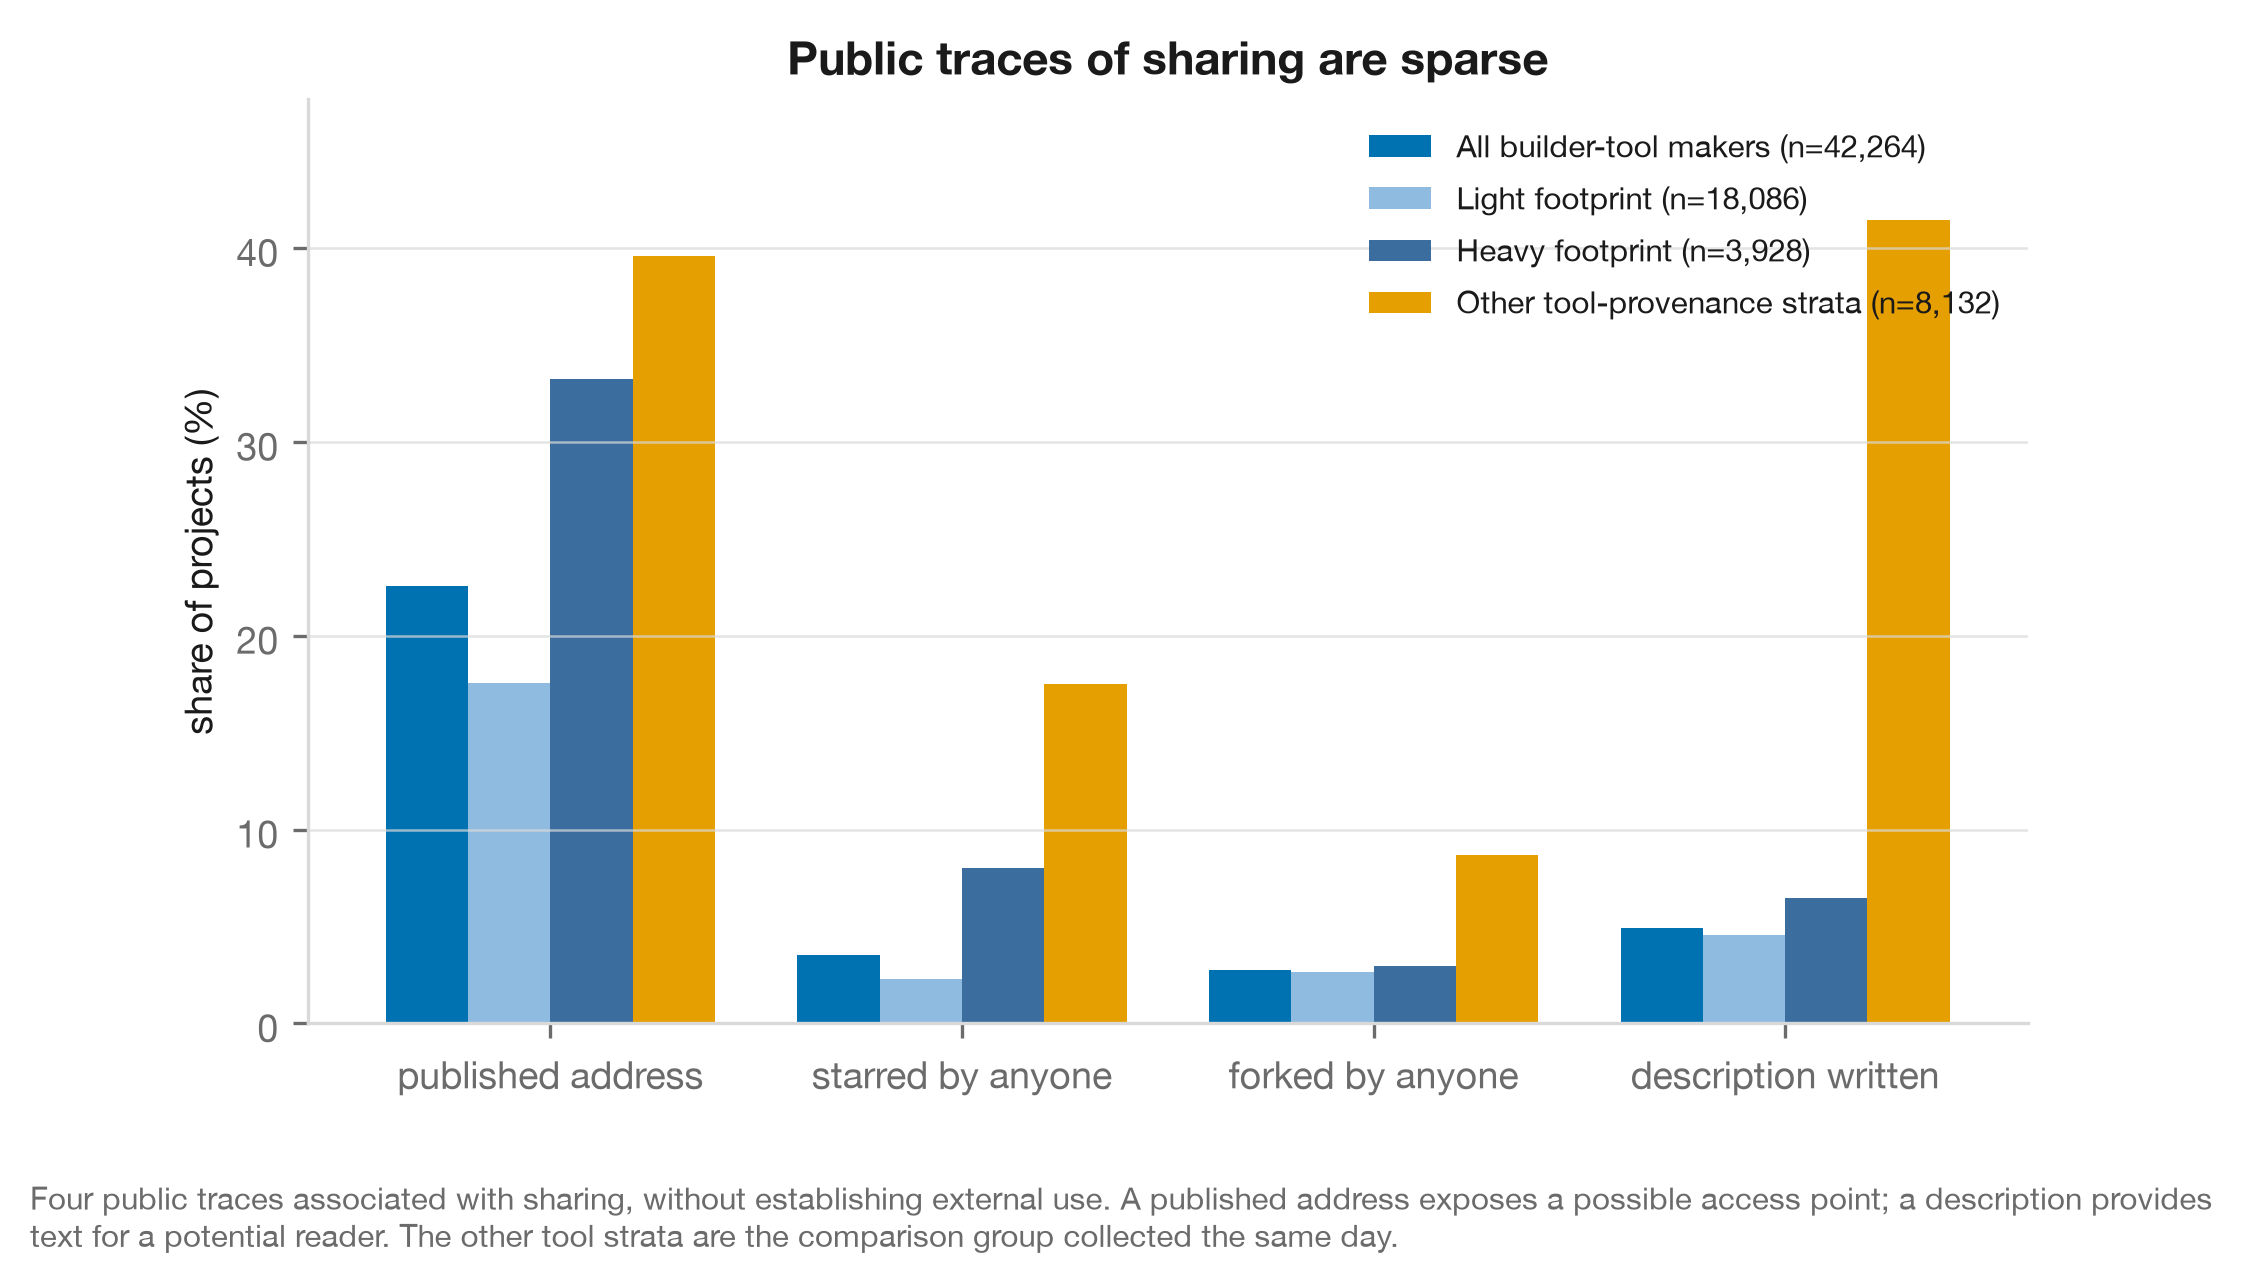

                     All builder-tool makers  Light footprint  Heavy footprint  Other tool-provenance strata
published address                       22.6             17.6             33.3                          39.6
starred by anyone                        3.5              2.3              8.0                          17.5
forked by anyone                         2.7              2.7              3.0                           8.7
description written                      4.9              4.6              6.5                          41.5


In [12]:
# Footprint groups, defined once here and reused by the report's sensitivity check.
bio = folk["owner_has_bio"].fillna(False).astype(bool)
light = (~bio) & (folk["owner_followers"].fillna(0) <= 1) & (folk["owner_public_repos"].fillna(99) < 10)
heavy = bio & ((folk["owner_followers"].fillna(0) >= 10) | (folk["owner_public_repos"].fillna(0) >= 30))

def travel(g):
    return {
        "published address": 100 * g["homepage_url"].notna().mean(),
        "starred by anyone": 100 * (g["stars"] > 0).mean(),
        "forked by anyone": 100 * (g["forks"] > 0).mean(),
        "description written": 100 * g["has_description"].astype(bool).mean(),
    }
groups = {"All builder-tool makers": travel(folk), "Light footprint": travel(folk[light]),
          "Heavy footprint": travel(folk[heavy]), "Other tool-provenance strata": travel(pro)}
tv = pd.DataFrame(groups)

fig, ax = plt.subplots(figsize=(7.4, 4.0))
x = np.arange(len(tv.index)); wbar = 0.2
cols = [fv.STRATUM_COLOUR["lovable"], "#8fbbe0", "#3b6e9e", fv.STRATUM_COLOUR["replit"]]
for i, (name, colour) in enumerate(zip(tv.columns, cols)):
    ax.bar(x + (i - 1.5) * wbar, tv[name].values, wbar, label=f"{name} (n={ {0: len(folk), 1: int(light.sum()), 2: int(heavy.sum()), 3: len(pro)}[i]:,})", color=colour)
ax.set_xticks(x); ax.set_xticklabels(tv.index)
ax.set_ylabel("share of projects (%)"); ax.set_ylim(0, max(45, tv.values.max() * 1.15))
ax.set_title("Public traces of sharing are sparse")
ax.legend(fontsize=7.5, loc="upper right"); ax.grid(axis="x", visible=False)
fv.save(fig, "fig9_does_it_travel",
        "Four public traces associated with sharing, without establishing external use. "
        "A published address exposes a possible access point; a description "
        "provides text for a potential reader. The other tool strata are the comparison group collected the same day.")
print(tv.round(1).to_string())

## 8. The dictionary and the selected model read the same sample

This comparison uses the completed 1,000-name Kind run and the model version
recorded in `accepted.json`. Each instrument's family shares use the names it
could classify. Exact agreement uses the names both could classify.

The final Kind evaluation agreed with three of ten reference labels. That result
limits what can be inferred from the larger run. The following chart compares
the instruments' outputs, with their different coverage stated beside them.

Selected Kind sample: 1,000; dictionary classifies 449; model classifies 718 (71.8%).
Jointly classified: 403; exact matches: 256 (63.5%).
Neither classifies: 23.6%.


saved figures/fig10_two_instruments.png and .pdf


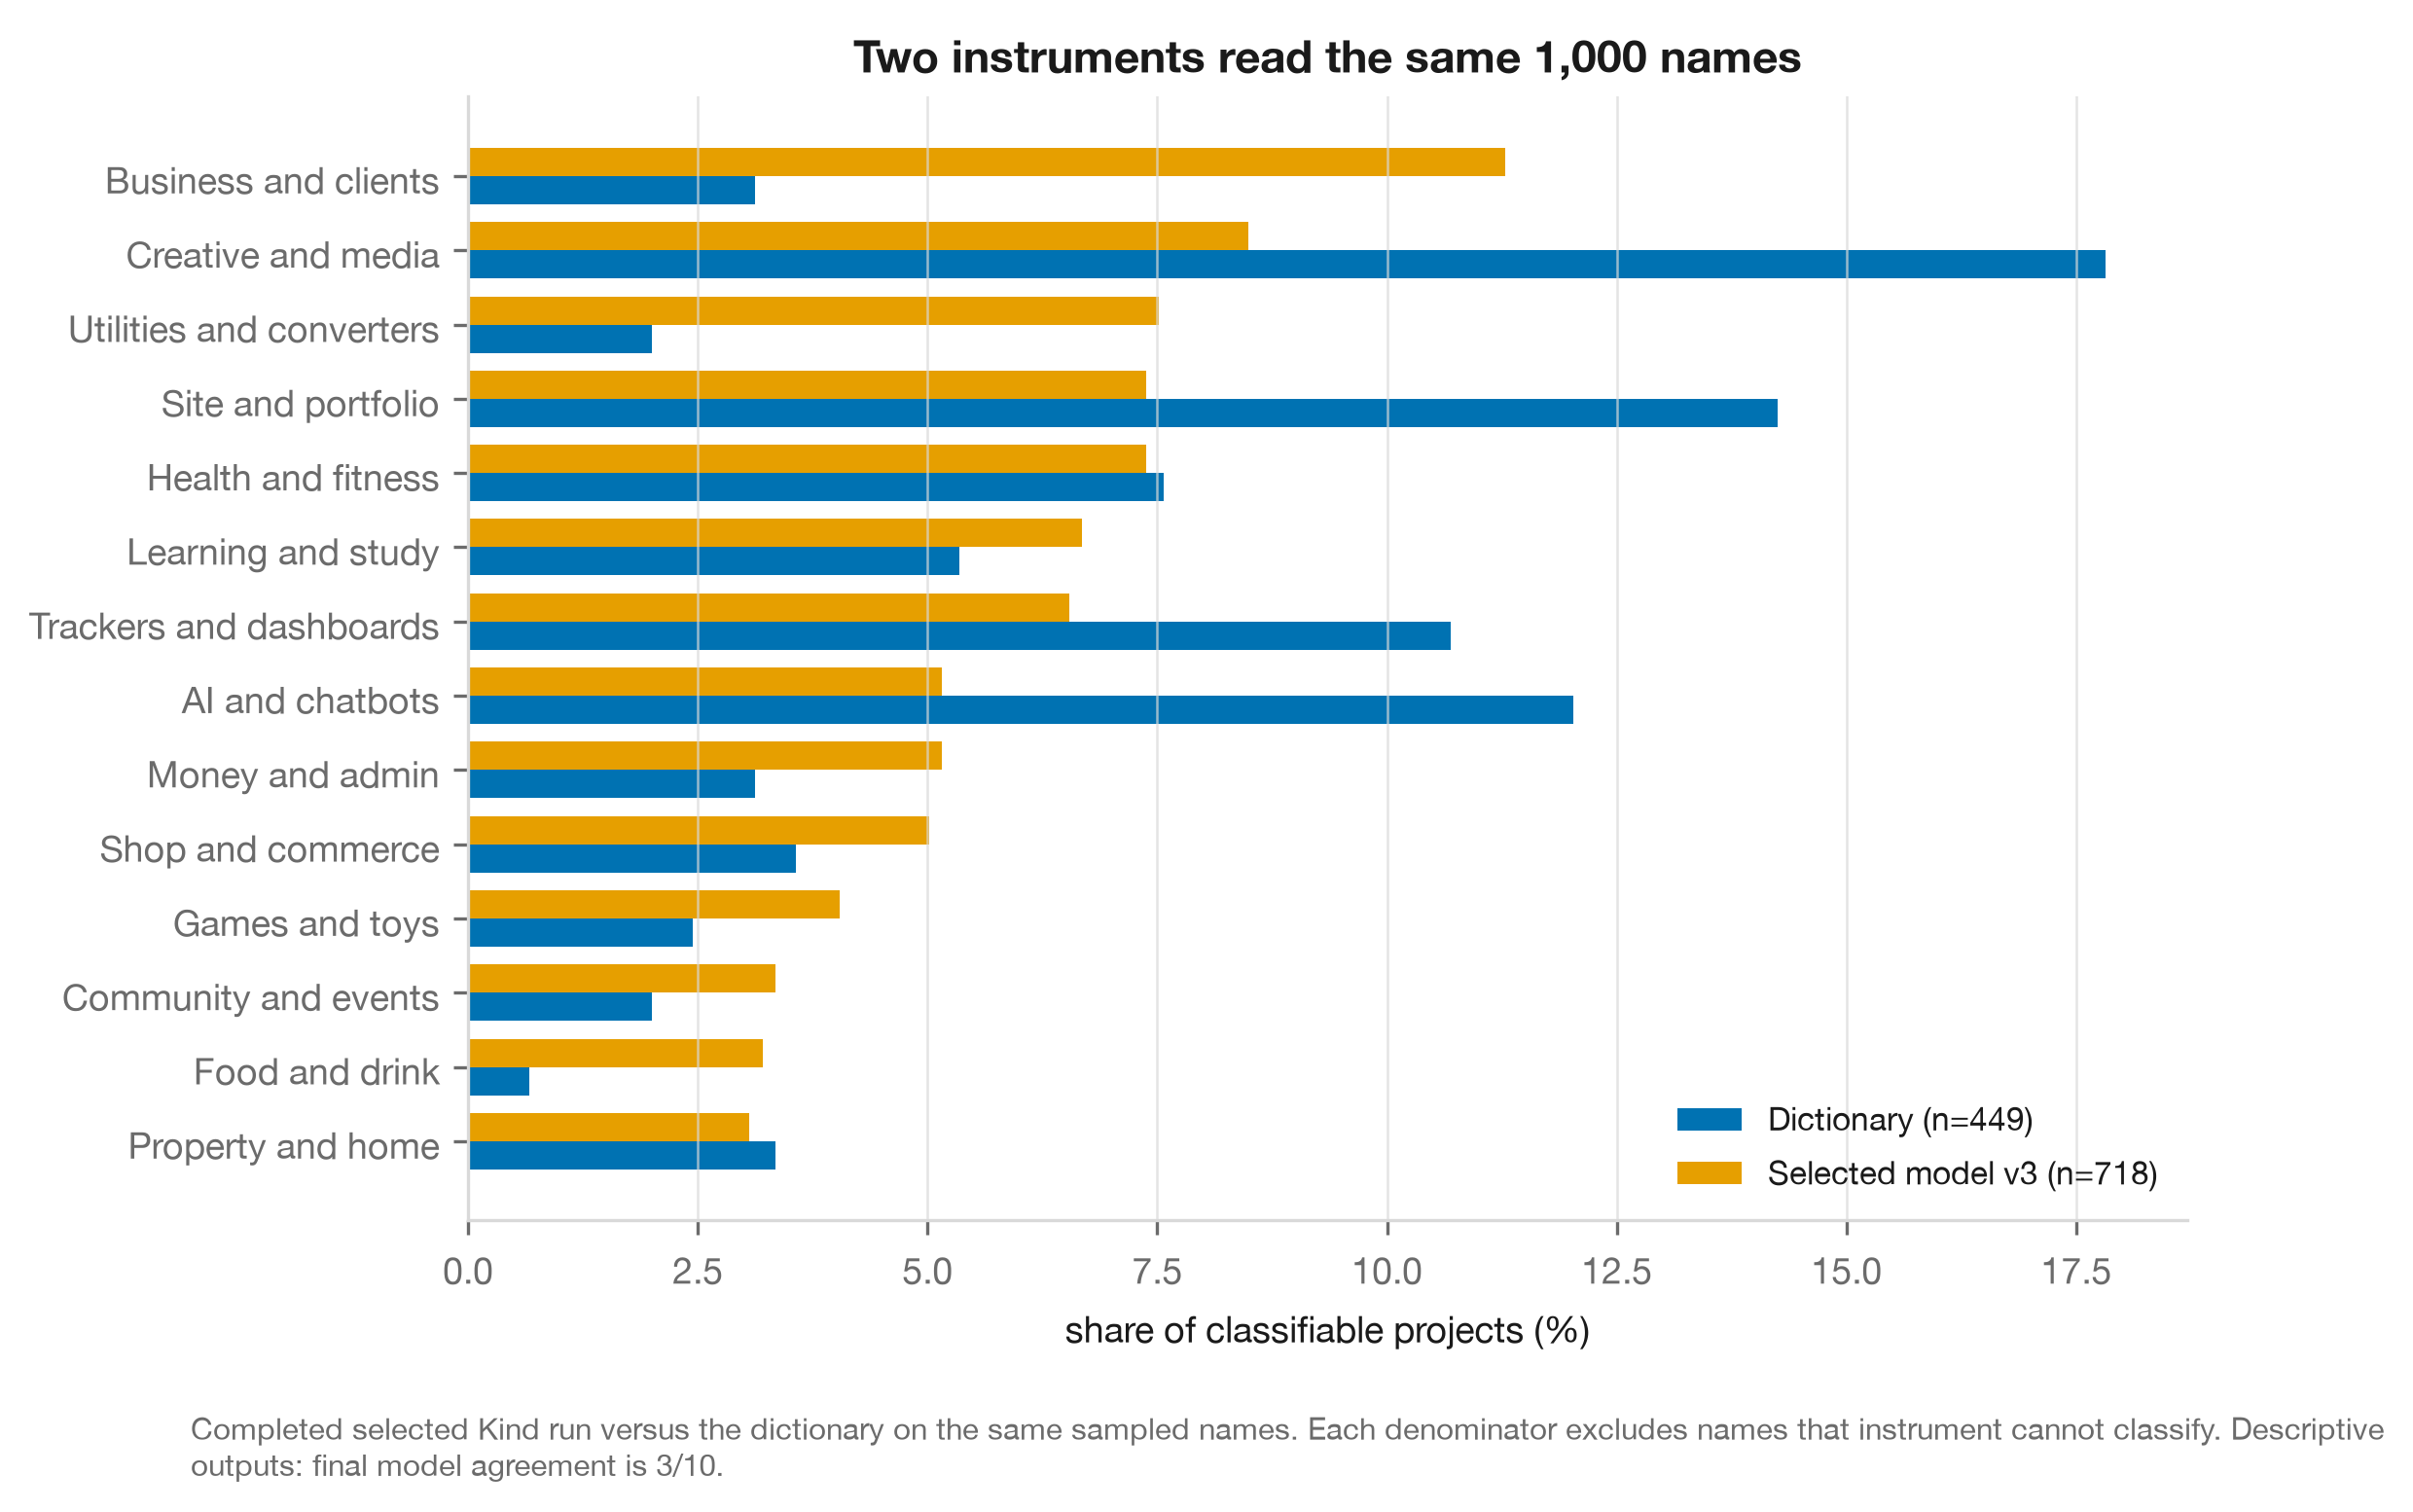

In [13]:
import json
ALIGN = ROOT / "data" / "processed" / "alignment"
accepted = json.loads((ALIGN / "accepted.json").read_text())
choice = accepted["kind"]
selected_path = ALIGN / f"scale_kind_{choice['model']}_v{choice['prompt_version']}_n1000_seed20260913.csv"
selected = pd.read_csv(selected_path, dtype=str, keep_default_na=False)
assert len(selected) == 1000 and selected["repo_id"].is_unique
assert selected["model"].eq(choice["model"]).all()
assert selected["prompt_version"].eq(str(choice["prompt_version"])).all()
two = folk[["repo_id", "genre", "auto_slug"]].merge(
    selected[["repo_id", "label"]], on="repo_id", how="inner", validate="one_to_one")
assert len(two) == len(selected)
dictionary_readable = ~two["auto_slug"] & ~two["genre"].isin(UNREADABLE)
model_readable = ~two["label"].isin(["Cannot tell", "Generic or brand-style name"])
joint = dictionary_readable & model_readable
print(f"Selected Kind sample: {len(two):,}; dictionary classifies {dictionary_readable.sum():,}; "
      f"model classifies {model_readable.sum():,} ({100 * model_readable.mean():.1f}%).")
print(f"Jointly classified: {joint.sum():,}; exact matches: "
      f"{two.loc[joint, 'genre'].eq(two.loc[joint, 'label']).sum():,} "
      f"({100 * two.loc[joint, 'genre'].eq(two.loc[joint, 'label']).mean():.1f}%).")
print(f"Neither classifies: {100 * (~dictionary_readable & ~model_readable).mean():.1f}%.")
d_share = two.loc[dictionary_readable, "genre"].value_counts(normalize=True) * 100
j_share = two.loc[model_readable, "label"].value_counts(normalize=True) * 100
fams = list(j_share.head(14).index)
fig, ax = plt.subplots(figsize=(7.6, 5.0))
y = np.arange(len(fams)); h = 0.38
ax.barh(y + h / 2, [d_share.get(f, 0) for f in fams], h,
        color=fv.STRATUM_COLOUR["lovable"], label=f"Dictionary (n={dictionary_readable.sum():,})")
ax.barh(y - h / 2, [j_share.get(f, 0) for f in fams], h,
        color=fv.STRATUM_COLOUR["replit"], label=f"Selected model v{choice['prompt_version']} (n={model_readable.sum():,})")
ax.set_yticks(y); ax.set_yticklabels(fams); ax.invert_yaxis()
ax.set_xlabel("share of classifiable projects (%)"); ax.grid(axis="y", visible=False)
ax.set_title("Two instruments read the same 1,000 names")
ax.legend(fontsize=8, loc="lower right")
fv.save(fig, "fig10_two_instruments",
        "Completed selected Kind run versus the dictionary on the same sampled names. "
        "Each denominator excludes names that instrument cannot classify. "
        "Descriptive outputs: final model agreement is 3/10.")

## 9. Alignment, final evaluation and saved production samples

Each judgment has 50 reference items in a fixed order. The first 40 formed the
development set, with results reported in four blocks of ten. These blocks
summarize predictions from the same prompt version. They do not represent four
independently fitted models.

The development target was mean agreement of at least 80 percent, with no block
below 70 percent. Maker v2 and Name style v3 met it. After three unsuccessful
versions, Kind and Audience v3 were retained as the best available below the
target. Those choices are recorded in `accepted.json`.

The table reproduces the scores from saved predictions and final reference
labels. The final set contains ten items per judgment, giving wide Wilson
intervals. Earlier Kind baselines already included predictions for its final
items, so the files cannot establish that those items were wholly untouched.

Human judgments could draw on linked applications and source evidence, while the
model read names. Agreement therefore reflects both classification and a
difference in available evidence. Weak final agreement limits interpretation of
the larger samples, including where development scores met the target.

     task           model  prompt_version                        split  n  agree  agreement  wilson_lo  wilson_hi  kappa  mean_dev_agreement  min_fold_agreement passes
 audience claude-sonnet-5               1            working 40 pooled 40     20      0.500      0.352      0.648  0.140               0.500               0.400  False
 audience claude-sonnet-5               2            working 40 pooled 40     29      0.725      0.572      0.839  0.522               0.725               0.600  False
 audience claude-sonnet-5               3            working 40 pooled 40     31      0.775      0.625      0.877  0.601               0.775               0.700  False
 audience claude-sonnet-5               3 sealed 10 (selected version) 10      5      0.500      0.237      0.763  0.219                 NaN                 NaN    NaN
     kind claude-sonnet-5               0            working 40 pooled 39     24      0.615      0.459      0.751  0.587               0.611               0.444

saved figures/fig11_alignment_history.png and .pdf


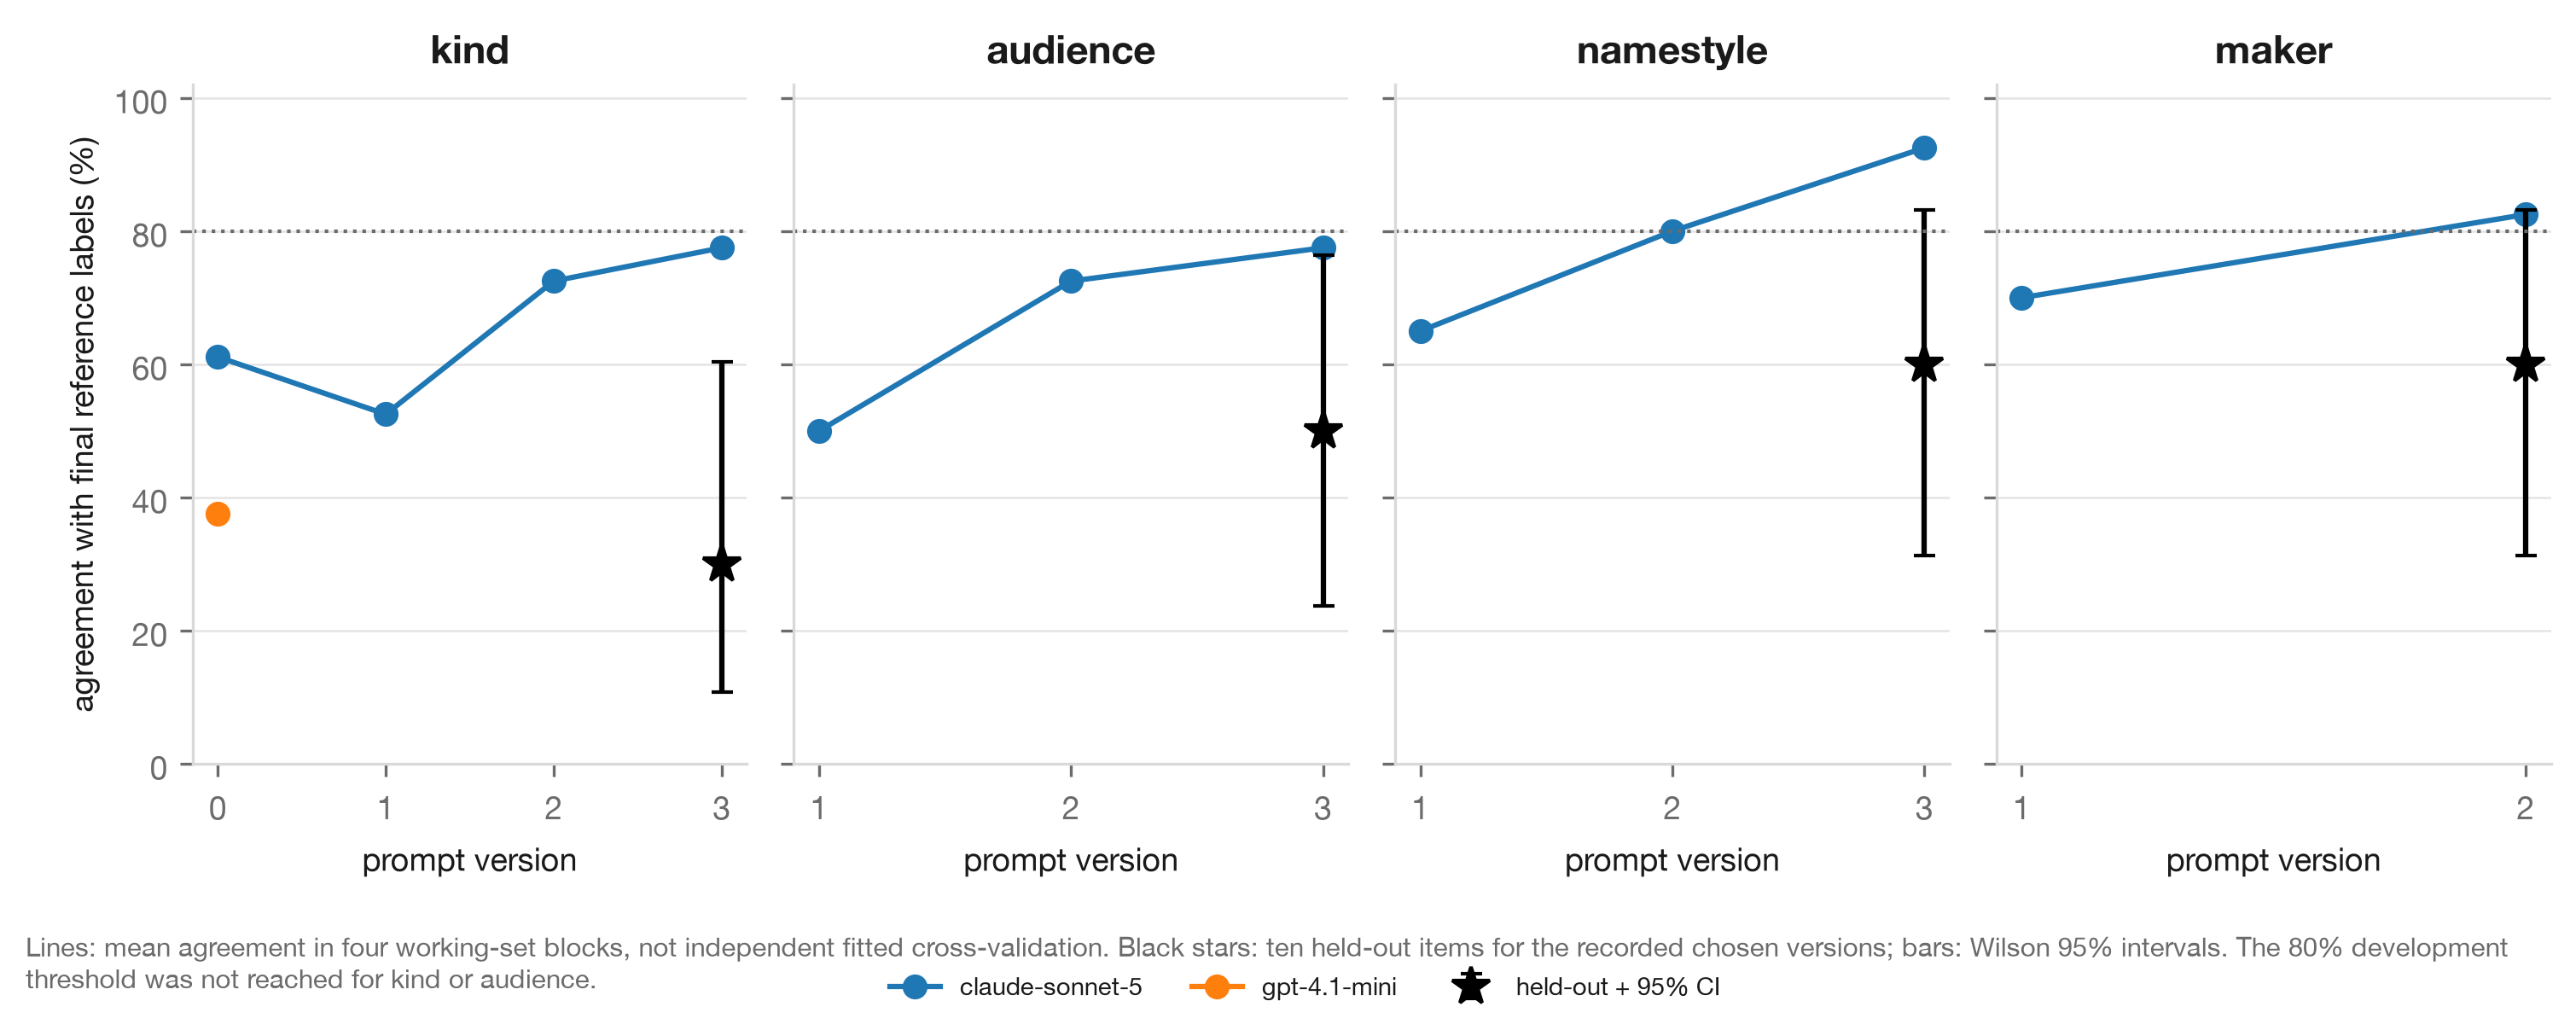


Saved production sample completion:
     task                                                      file  target  saved rows  valid labels  complete
     kind      scale_kind_claude-sonnet-5_v3_n1000_seed20260913.csv    1000        1000          1000      True
 audience  scale_audience_claude-sonnet-5_v3_n1000_seed20260913.csv    1000        1000          1000      True
namestyle scale_namestyle_claude-sonnet-5_v3_n1000_seed20260913.csv    1000         874           874     False

Descriptive output shares, subject to the held-out agreement limitations:
     task                                                                         label    n  count  share percent
     kind                                                                   Cannot tell 1000    254          25.40
     kind                                                          Business and clients 1000     81           8.10
     kind                                                            Creative and media 1000   

In [14]:
import json
import alignment_history as ah

ALIGN = ROOT / "data" / "processed" / "alignment"
accepted = json.loads((ALIGN / "accepted.json").read_text())
hist = ah.build()   # saved predictions + final labels. No external calls
summary = hist[hist["split"].eq("working 40 pooled") | hist["split"].str.startswith("sealed")]
columns = ["task", "model", "prompt_version", "split", "n", "agree", "agreement",
           "wilson_lo", "wilson_hi", "kappa", "mean_dev_agreement", "min_fold_agreement", "passes"]
print(summary[columns].round(3).to_string(index=False))
summary.to_csv(ROOT / "figures" / "table_alignment_verification.csv", index=False)

# Draw the complete development history with held-out estimates at fixed choices.
fig, axes = plt.subplots(1, 4, figsize=(10, 3.6), sharey=True)
for ax, task in zip(axes, ["kind", "audience", "namestyle", "maker"]):
    g = hist[hist["task"].eq(task) & hist["split"].eq("working 40 pooled")]
    for model, gm in g.groupby("model"):
        gm = gm.sort_values("prompt_version")
        ax.plot(gm["prompt_version"], 100 * gm["mean_dev_agreement"], marker="o", label=model)
    held = hist[hist["task"].eq(task) & hist["split"].str.startswith("sealed")]
    for _, row in held.iterrows():
        ax.errorbar(row["prompt_version"], 100 * row["agreement"],
                    yerr=[[100 * (row["agreement"] - row["wilson_lo"])],
                          [100 * (row["wilson_hi"] - row["agreement"])]],
                    fmt="*", markersize=11, color="black", capsize=3, label="held-out + 95% CI")
    ax.axhline(80, ls=":", color=fv.MUTED, lw=1)
    ax.set_title(task); ax.set_xlabel("prompt version"); ax.set_ylim(0, 102)
    ax.set_xticks(sorted(g["prompt_version"].unique())); ax.grid(axis="x", visible=False)
axes[0].set_ylabel("agreement with final reference labels (%)")
handles, labels = [], []
for ax in axes:
    for handle, label in zip(*ax.get_legend_handles_labels()):
        if label not in labels:
            handles.append(handle); labels.append(label)
fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=7, bbox_to_anchor=(0.5, -0.12))
fig.tight_layout()
fv.save(fig, "fig11_alignment_history",
        "Lines: mean agreement in four working-set blocks, not independent fitted cross-validation. "
        "Black stars: ten held-out items for the recorded chosen versions; bars: Wilson 95% intervals. "
        "The 80% development threshold was not reached for kind or audience.")

# Check actual completed rows, not the n1000 filename or an assumed total.
production_rows, share_rows = [], []
for task in ["kind", "audience", "namestyle"]:
    spec = json.loads((ALIGN / "evaluation_tasks.json").read_text())[task]
    choice = accepted[task]
    paths = [ALIGN / f"scale_{task}_{choice['model']}_v{choice['prompt_version']}_n1000_seed20260913.csv"]
    for path in sorted(paths):
        data = pd.read_csv(path, dtype=str, keep_default_na=False)
        if data["repo_id"].duplicated().any():
            raise ValueError(f"Duplicate production ids in {path.name}")
        valid = data[data["label"].isin(spec["options"])]
        production_rows.append({"task": task, "file": path.name, "target": 1000,
                               "saved rows": len(data), "valid labels": len(valid),
                               "complete": len(valid) == 1000})
        for label, count in valid["label"].value_counts().items():
            share_rows.append({"task": task, "label": label, "n": len(valid),
                               "count": count, "share percent": 100 * count / len(valid)})
production = pd.DataFrame(production_rows)
production_shares = pd.DataFrame(share_rows)
print("\nSaved production sample completion:")
print(production.to_string(index=False))
print("\nDescriptive output shares, subject to the held-out agreement limitations:")
print(production_shares.round(2).to_string(index=False))
production.to_csv(ROOT / "figures" / "table_production_completion.csv", index=False)
production_shares.to_csv(ROOT / "figures" / "table_production_label_shares.csv", index=False)

# The saved maker score is a ranking proxy, not an occupation probability.
from maker_score import auc
maker_items = pd.read_csv(ALIGN / "maker_score_items.csv")
maker_rows = []
for split, group in [("working 40", maker_items.iloc[:40]), ("held-out 10", maker_items.iloc[40:50])]:
    for column in ["det_score", "full_score"]:
        maker_rows.append({"split": split, "score": column, "n": len(group),
                           "positive reference": int(group["y"].sum()),
                           "negative reference": int(len(group) - group["y"].sum()),
                           "AUC": auc(group[column].to_numpy(), group["y"].to_numpy())})
maker_verification = pd.DataFrame(maker_rows)
print("\nSaved maker-score discrimination (NaN means AUC is undefined):")
print(maker_verification.round(3).to_string(index=False))
maker_verification.to_csv(ROOT / "figures" / "table_maker_score_verification.csv", index=False)
print("The score's negative class is Cannot tell, not demonstrated non-professionals. "
      "The final ten contain four professional labels and six Cannot tell labels; "
      "discrimination between those answers does not establish occupational validity. "
      "Only the deterministic score exists across the stratum; the coder term exists for 50 items.")

## 10. Reference-label coverage and sampling limits

The four completed tasks contain 50 judgments each. This cell checks the frozen
reference labels, permitted answers, rejection counts and sampling seeds.
Kind used 23 adapted software families, a generic-name option and Cannot tell.
Audience used household and producer sectors. Maker used three interpretive
categories, and naming used the trademark distinctiveness spectrum. Each task
allowed a Cannot tell answer. The exact options and sampling details are saved
in `evaluation_tasks.json`.

The samples were drawn proportionally across strata, using largest-remainder
allocation and excluding auto-generated names. Fifty observations allow only
limited precision, especially within categories. The sample-size calculation
below illustrates that constraint. It does not account for classification error.

An older 105-row dictionary-validation sheet has no completed answers. The
alignment scores use the final evaluator labels. A second independent rater
would be needed to estimate agreement between people.

In [15]:
import csv
import validation_sample as vs

coverage = []
for task in ["kind", "audience", "namestyle", "maker"]:
    spec = json.loads((ALIGN / "evaluation_tasks.json").read_text())[task]
    snapshot = pd.read_csv(ALIGN / "evaluation_labels.csv", dtype=str, keep_default_na=False)
    current = snapshot[snapshot["task_id"].eq(task)].copy()
    invalid = current[current["verdict"].eq("label") & ~current["human_label"].isin(spec["options"])]
    if not invalid.empty:
        raise ValueError(f"Invalid frozen vocabulary labels in {task}")
    assert len(current) == spec["sample_size"] and current["item_id"].is_unique
    coverage.append({"task": task, "sample": len(current),
                     "labelled": int(current["verdict"].eq("label").sum()),
                     "rejected": int(current["verdict"].eq("reject").sum()),
                     "seed": spec["sampling"]["seed"]})
coverage = pd.DataFrame(coverage)
print(coverage.to_string(index=False))
coverage.to_csv(ROOT / "figures" / "table_reference_coverage.csv", index=False)

sheet, answers, meta = vs.draw(df.assign(repo_slug=df["repo_slug"]), cb)
print(f"\nLegacy sample-design populations: classified {meta['N_classified']:,}; "
      f"unclassified {meta['N_unclassified']:,}.")
for n in (10, 40, 50, 105):
    print(f"n={n:>3}: illustrative 95% margin +/- {vs.margin_of_error(n, 0.8, meta['N_classified']):.1%}")
legacy = pd.read_csv(ROOT / "data" / "processed" / "validation_sheet.csv", keep_default_na=False)
answer_columns = [column for column in legacy if column.startswith("YOUR_")]
print("Legacy sheet completed answer cells:", int(legacy[answer_columns].ne("").sum().sum()),
      "of", len(legacy) * len(answer_columns), "(excluded from validation).")

     task  sample  labelled  rejected     seed
     kind      50        50         0 20260913
 audience      50        50         0 20260913
namestyle      50        50         0 20260916
    maker      50        50         0 20260915



Legacy sample-design populations: classified 16,796; unclassified 24,241.
n= 10: illustrative 95% margin +/- 24.8%
n= 40: illustrative 95% margin +/- 12.4%
n= 50: illustrative 95% margin +/- 11.1%
n=105: illustrative 95% margin +/- 7.6%
Legacy sheet completed answer cells: 0 of 420 (excluded from validation).


## 11. Reproducibility

The notebook writes each chart as a 300 dpi PNG and a vector PDF. Numerical
verification tables are saved in the same folder. Collection outputs, model
predictions and final labels are read from the saved files, with sampling seeds
recorded in the public task metadata.

`src/build_notebook.py` generates the notebook source. Rebuilding clears its
outputs, which must then be restored by running `python tools/run_notebook.py`.
Package versions are pinned in `requirements.txt`. The data statement and
`report/validation-method.md` explain how the inputs should be interpreted.

In [16]:
import platform, sklearn, matplotlib
print("environment")
print(f"  python      {platform.python_version()}")
print(f"  pandas      {pd.__version__}")
print(f"  numpy       {np.__version__}")
print(f"  matplotlib  {matplotlib.__version__}")
print(f"  scikit-learn {sklearn.__version__}")
print(f"  seed        {RANDOM_SEED}")
print()
print("figures written:")
for p in sorted((ROOT / "figures").glob("*.png")):
    print("  ", p.name)

environment
  python      3.14.6
  pandas      2.3.3
  numpy       2.5.3
  matplotlib  3.11.2
  scikit-learn 1.9.1
  seed        20260912

figures written:
   appendix_evaluator_menu.png
   appendix_evaluator_methods.png
   appendix_evaluator_task.png
   fig10_two_instruments.png
   fig11_alignment_history.png
   fig3_what_people_make.png
   fig4_naming_vocabulary.png
   fig5_who_makes_it.png
   fig6_commerce_gradient.png
   fig7_made_to_last.png
   fig8_what_the_census_misses.png
   fig9_does_it_travel.png
